# io_method sweep — async I/O engine, on tpch (COLD, PG18+)

Sibling of `sharedBuffers.ipynb`. Analyses **`logs/io_method/`**: the tpch
workload run under `iom_sync`, `iom_worker_io1/3/6` (worker pool of 1/3/6
`io_workers`) and `iom_io_uring`, base and indexed (`_idx`). All four already-studied knobs are pinned so this parameter is the only thing moving: **shared_buffers = 4 GB, effective_cache_size = 12 GB, work_mem = 64 MB, max_parallel_workers_per_gather = 4.**

These are **COLD** runs (the I/O engine only matters off disk) and PG18-only
(`io_method` is new in 18). This is a categorical sweep — the values are distinct
engines, not a continuum. Data comes from `query_cold_<db>.csv`. A cohort is
`(io_method | index_status)`.

## 1. Fetch the io_method logs → local `iom_cache/`

Walks `logs/io_method/iom_*/`, downloads the `query_cold_*` files (base + `_idx`),
mirrors them into `iom_cache/`, and falls back to that cache on a failed fetch.

In [1]:
# %pip install paramiko pandas matplotlib
import io, re, time
from pathlib import Path
import numpy as np
import pandas as pd
import paramiko

SSH_HOST = "192.168.1.42"
SSH_USER = "user01"
SSH_PASS = "a"                       # demo credential
REMOTE_DIR = "/home/user01/GreenSQL/logs/io_method"
CACHE_DIR = Path("iom_cache")        # dedicated cache for this sweep
RETRIES = 5

PARAM_NAME = "io_method"
X_MODE = "linear"                 # "log" -> log2 x-axis; else linear/categorical
TEMP = "cold"                    # "warm" or "cold"

# file suffix -> index status
VARIANTS = {"tpch": "base", "tpch_idx": "idx"}

ORDER = ['sync', 'worker_io1', 'worker_io3', 'worker_io6', 'io_uring']
LABELS = {'sync': 'sync', 'worker_io1': 'worker io1', 'worker_io3': 'worker io3 (def)', 'worker_io6': 'worker io6', 'io_uring': 'io_uring'}


def p_to_val(name):
    m = re.match(r"iom_(.+)$", str(name))
    if not m:
        return None
    k = m.group(1)
    return ORDER.index(k) if k in ORDER else None


def p_label(v):
    return LABELS[ORDER[int(v)]]


def fetch_over_ssh():
    last = None
    for attempt in range(1, RETRIES + 1):
        try:
            cl = paramiko.SSHClient()
            cl.set_missing_host_key_policy(paramiko.AutoAddPolicy())
            cl.connect(SSH_HOST, username=SSH_USER, password=SSH_PASS,
                       timeout=45, banner_timeout=45, auth_timeout=45)
            try:
                with cl.open_sftp() as sftp:
                    blobs = {}
                    for d in sftp.listdir(REMOTE_DIR):
                        if p_to_val(d) is None:
                            continue
                        dd = f"{REMOTE_DIR}/{d}"
                        try:
                            here = set(sftp.listdir(dd))
                        except IOError:
                            continue
                        for suf in VARIANTS:
                            fn = f"query_cold_{suf}.csv"
                            if fn in here:
                                blobs[f"{d}/{fn}"] = sftp.open(f"{dd}/{fn}").read()
                    if not blobs:
                        raise RuntimeError(f"no CSVs under {REMOTE_DIR}")
                    return blobs
            finally:
                cl.close()
        except Exception as exc:
            last = exc
            print(f"  attempt {attempt}/{RETRIES} failed: {type(exc).__name__}")
            time.sleep(3)
    raise RuntimeError(f"SSH failed after {RETRIES} attempts: {last}")


def load():
    try:
        blobs = fetch_over_ssh()
        CACHE_DIR.mkdir(parents=True, exist_ok=True)
        for rel, b in blobs.items():
            p = CACHE_DIR / rel
            p.parent.mkdir(parents=True, exist_ok=True)
            p.write_bytes(b)
        print(f"Fetched {PARAM_NAME} logs from {SSH_HOST}; cache '{CACHE_DIR}/' updated.")
        return blobs, "server"
    except Exception as exc:
        if not CACHE_DIR.exists():
            raise RuntimeError(f"{exc}\nNo cache at '{CACHE_DIR}/'.") from exc
        blobs = {p.relative_to(CACHE_DIR).as_posix(): p.read_bytes()
                 for p in CACHE_DIR.rglob("*.csv")}
        if not blobs:
            raise RuntimeError(f"{exc}\nCache '{CACHE_DIR}/' is empty.") from exc
        age_h = (time.time() - max((CACHE_DIR / r).stat().st_mtime
                                   for r in blobs)) / 3600
        print(f"\n!! {exc}")
        print(f"!! Falling back to cache '{CACHE_DIR}/' ({age_h:.1f} h old).\n")
        return blobs, "cache"


BLOBS, SOURCE = load()
vals = sorted(v for v in {p_to_val(rel.split('/')[0]) for rel in BLOBS} if v is not None)
print(f"source: {SOURCE};  {len(BLOBS)} files;  "
      f"{PARAM_NAME} values: {[p_label(v) for v in vals]}")

Fetched io_method logs from 192.168.1.42; cache 'iom_cache/' updated.
source: server;  10 files;  io_method values: ['sync', 'worker io1', 'worker io3 (def)', 'worker io6', 'io_uring']


## 2. Build per-query data, keyed by `(io_method, index)`

**Cold** reduction (one row per single cold execution, averaged over repeats). The
five engines sit on a categorical x-axis in the order sync → worker(1/3/6) →
io_uring. A single PG version is kept if several are present.

In [2]:
def query_group(q):
    return re.sub(r"^queries/", "", str(q)).rsplit("/", 1)[0]


parts = []
for rel, b in BLOBS.items():
    dname, fn = rel.split("/", 1)
    val = p_to_val(dname)
    idx = "idx" if "_idx" in fn else "base"
    df = pd.read_csv(io.BytesIO(b))
    df["pval"] = val
    df["plabel"] = p_label(val)
    df["index_status"] = idx
    df["cohort"] = df["plabel"] + " | " + idx
    parts.append(df)

cr = pd.concat(parts, ignore_index=True)
cr["pg_version"] = cr["pg_version"].astype(str)
for c in ["elapsed_sec", "server_planning_ms", "server_execution_ms",
          "client_overhead_sec", "rapl_pkg_j", "rapl_core_j", "failed",
          "shared_hit_blks", "shared_read_blks", "temp_read_blks",
          "temp_written_blks", "workers_launched", "scan_nodes",
          "plan_nodes", "rows_removed_filter"]:
    if c in cr.columns:
        cr[c] = pd.to_numeric(cr[c], errors="coerce")
if "failed" in cr.columns:
    cr = cr[cr["failed"].fillna(0) == 0]
cr["time_s"] = cr["elapsed_sec"]
cr["plan_s"] = cr["server_planning_ms"] / 1000.0
cr["exec_s"] = cr["server_execution_ms"] / 1000.0
cr["overhead_s"] = cr["client_overhead_sec"]
cr["pkg_j"] = cr["rapl_pkg_j"].mask(lambda s: s < 0)
cr["core_j"] = cr["rapl_core_j"].mask(lambda s: s < 0)
KEY = ["cohort", "query", "pg_version"]

data = cr.groupby(KEY, as_index=False).agg(
    n_batches=("time_s", "size"),
    avg_time_s=("time_s", "mean"), time_std=("time_s", "std"),
    plan_s=("plan_s", "mean"), exec_s=("exec_s", "mean"),
    overhead_s=("overhead_s", "mean"),
    avg_pkg_j=("pkg_j", "mean"), pkg_j_std=("pkg_j", "std"),
    avg_core_j=("core_j", "mean"), core_j_std=("core_j", "std"),
    shared_hit=("shared_hit_blks", "mean"), shared_read=("shared_read_blks", "mean"),
    temp_read=("temp_read_blks", "mean"), temp_written=("temp_written_blks", "mean"),
    workers=("workers_launched", "mean"), scan_nodes=("scan_nodes", "mean"),
    rows_removed=("rows_removed_filter", "mean"),
    pval=("pval", "first"), plabel=("plabel", "first"),
    index_status=("index_status", "first"))
data["sql_file"] = data["query"].astype(str).str.split("/").str[-1]
data["group"] = data["query"].map(query_group)
data["qid"] = data["query"].astype(str).str.replace(
    r"^queries/tpch/tpch-queries/", "", regex=True)
blks = (data["shared_hit"] + data["shared_read"]).replace(0, np.nan)
data["cache_hit_pct"] = 100 * data["shared_hit"] / blks
data["read_mb"] = data["shared_read"] * 8 / 1024.0
data["temp_mb"] = (data["temp_read"] + data["temp_written"]) * 8 / 1024.0
data["cv_pct"] = 100 * data["time_std"] / data["avg_time_s"]
data["power_w"] = data["avg_pkg_j"] / data["avg_time_s"]
data["label"] = data["sql_file"]

# keep a single PG version so 14/16/18 are never silently averaged together
PGV = sorted(data["pg_version"].astype(str).unique())
if len(PGV) > 1:
    keep = max(PGV, key=lambda s: float(s.split(".")[0]))
    print(f"multiple PG versions present {PGV}; keeping {keep} "
          f"(set KEEP_PGVER to override).")
    KEEP_PGVER = keep
    data = data[data["pg_version"].astype(str) == KEEP_PGVER].copy()
else:
    KEEP_PGVER = PGV[0] if PGV else "?"

PVALS = sorted(data["pval"].dropna().unique())
IDX_ALL = [s for s in ["base", "idx"] if s in set(data["index_status"])]
colours = {"base": "#4c72b0", "idx": "#dd8452"}


def set_xaxis(ax):
    if X_MODE == "log":
        ax.set_xscale("log", base=2)
    ax.set_xticks(PVALS)
    ax.set_xticklabels([p_label(v) for v in PVALS])
    ax.set_xlabel(PARAM_NAME)


print(f"PG {KEEP_PGVER};  {len(data)} (cohort, query) rows; "
      f"{data['qid'].nunique()} queries; {data['group'].nunique()} query folders")
print(f"{PARAM_NAME}: {[p_label(v) for v in PVALS]}; index: {IDX_ALL}")
print(data.groupby(['plabel', 'index_status']).agg(
    queries=('qid', 'nunique'),
    total_runtime_s=('avg_time_s', 'sum'),
    total_energy_j=('avg_pkg_j', 'sum')).round(2).to_string())

PG 18.4;  530 (cohort, query) rows; 53 queries; 21 query folders
io_method: ['sync', 'worker io1', 'worker io3 (def)', 'worker io6', 'io_uring']; index: ['base', 'idx']
                               queries  total_runtime_s  total_energy_j
plabel           index_status                                          
io_uring         base               53           221.74         2779.33
                 idx                53           180.91         1796.10
sync             base               53           240.29         2717.50
                 idx                53           187.36         1750.91
worker io1       base               53           245.17         2856.54
                 idx                53           213.01         1810.06
worker io3 (def) base               53           228.05         2811.58
                 idx                53           184.78         1864.14
worker io6       base               53           223.21         2790.07
                 idx                53 

## 3. Main per-query plots (cold)

Same layout as `sharedBuffers` §3, on the cold numbers; the engines sit side by
side per query, indexed hatched. (The x-axis is categorical — engines, not a
scale.)

21 query folder(s) -> 23 figures


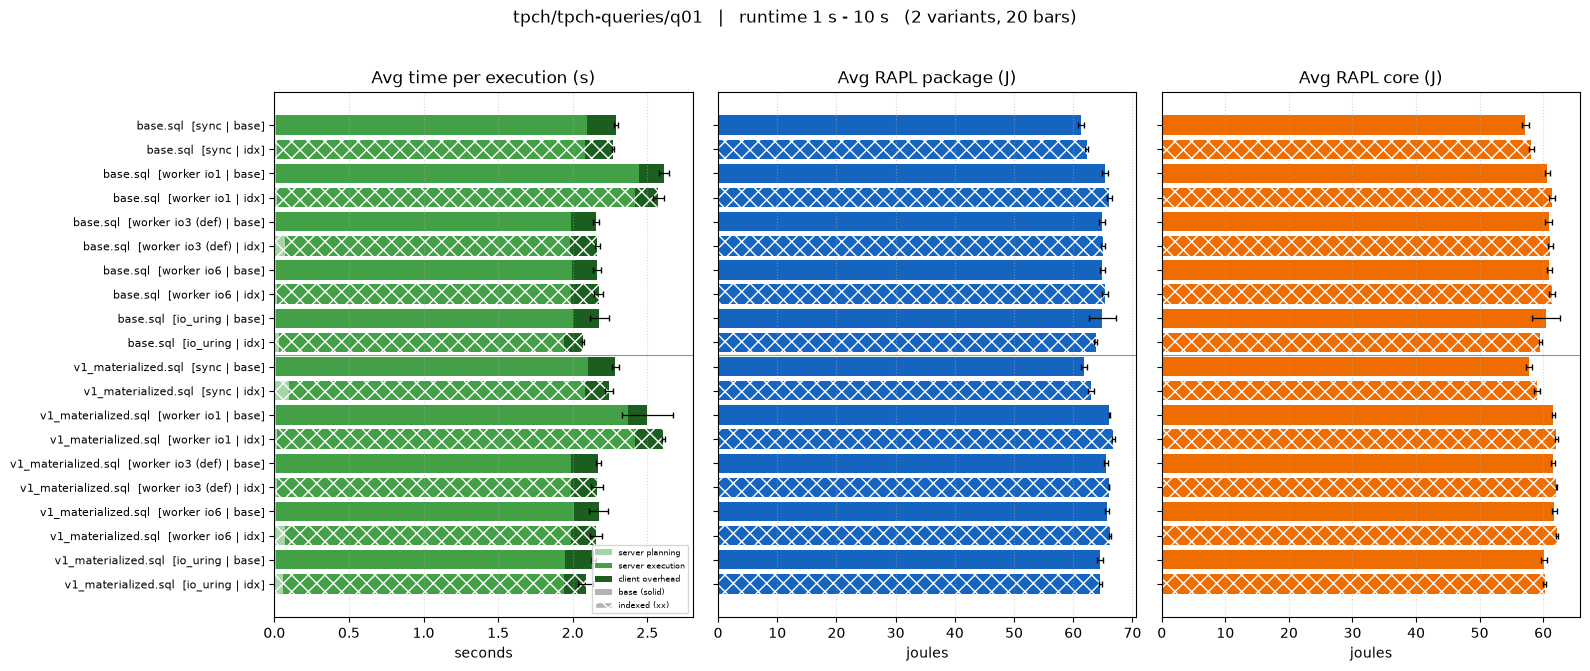

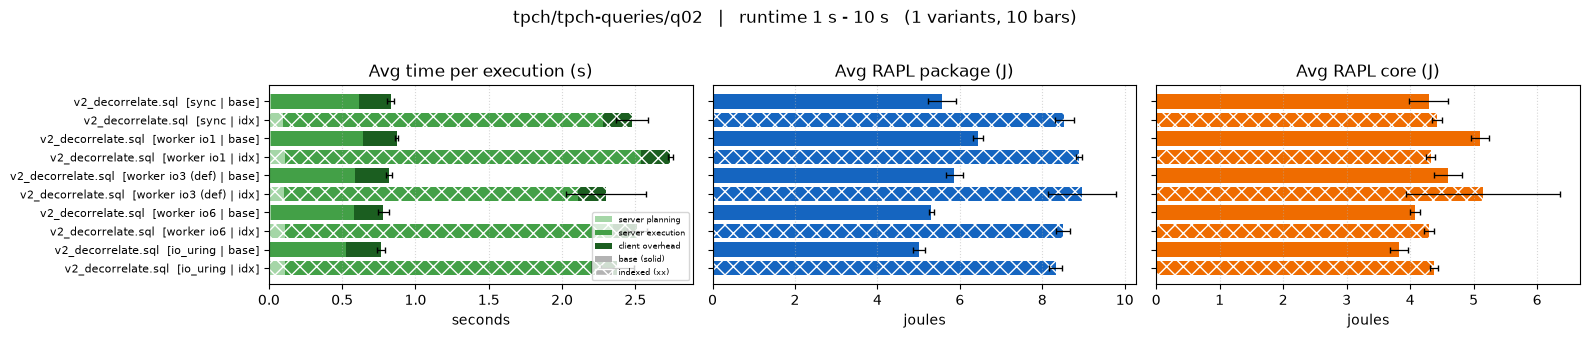

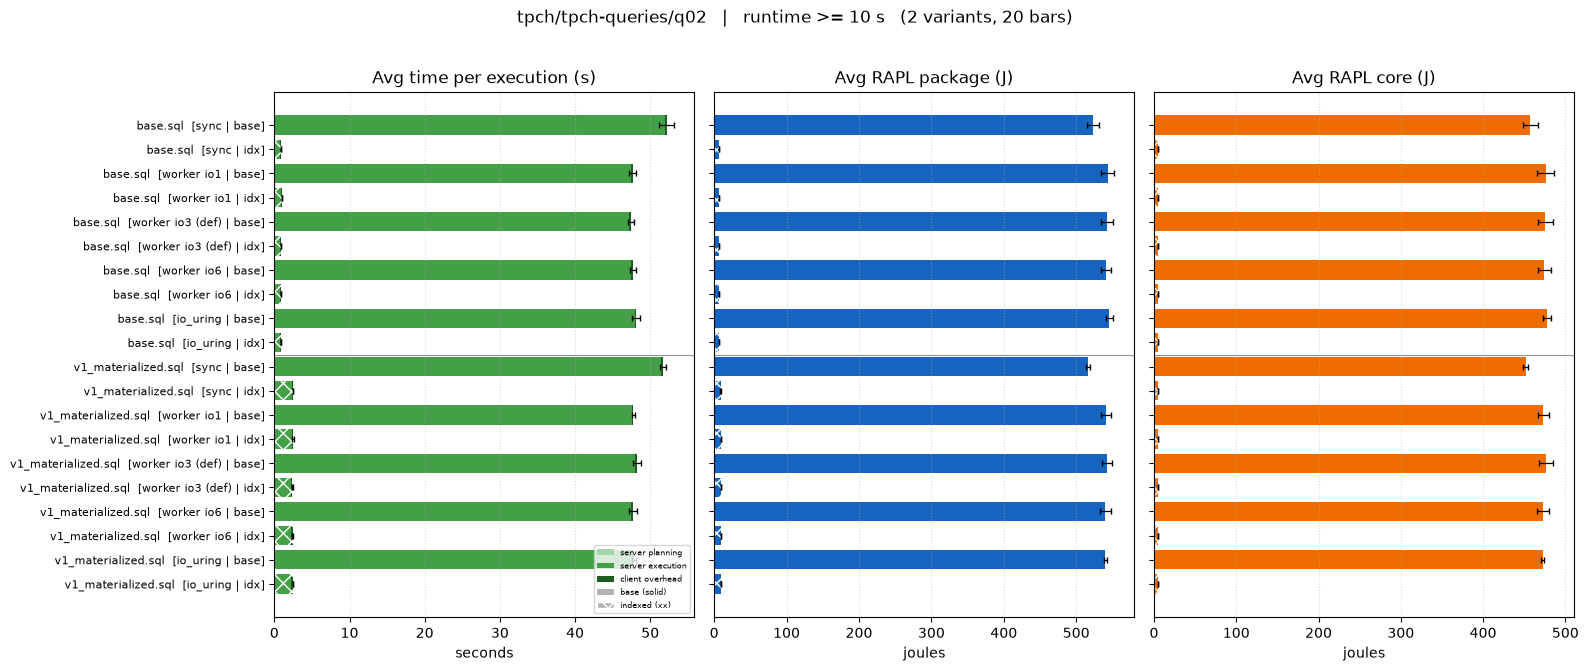

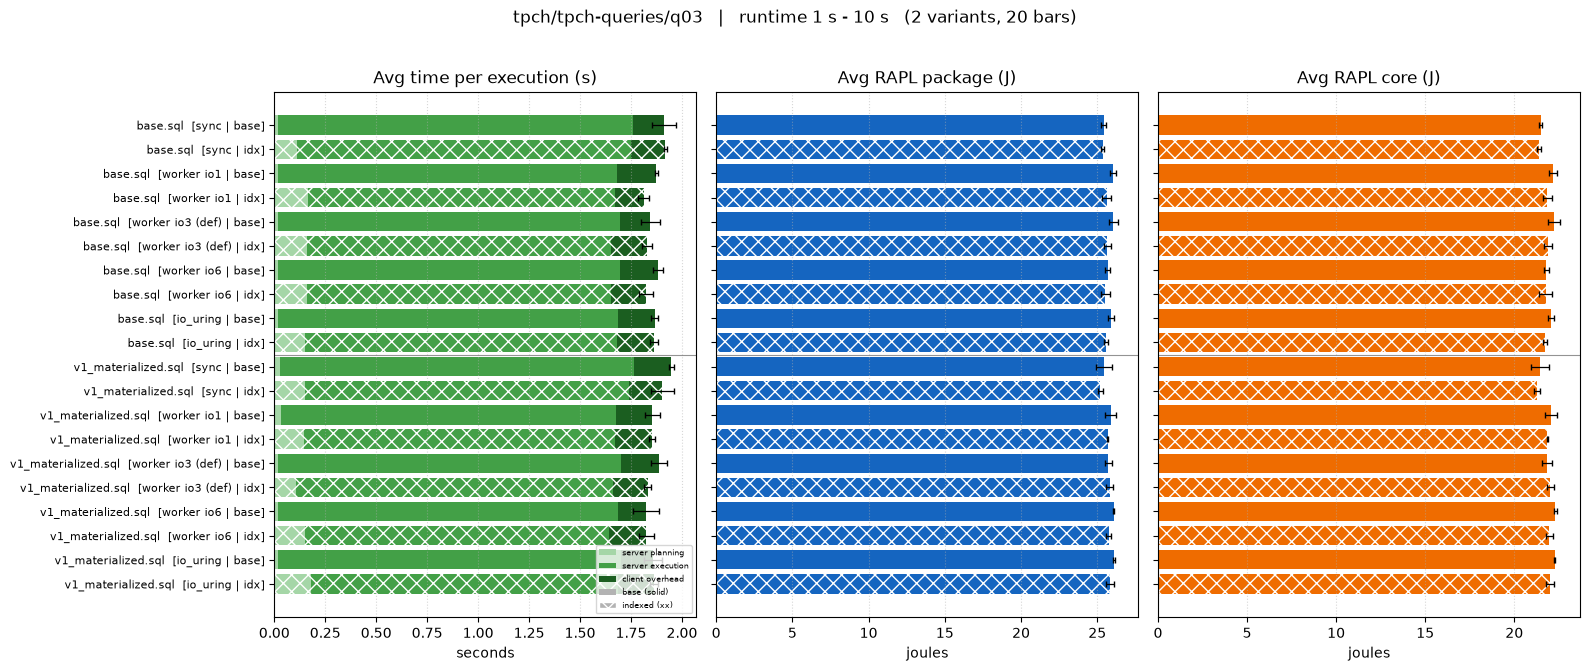

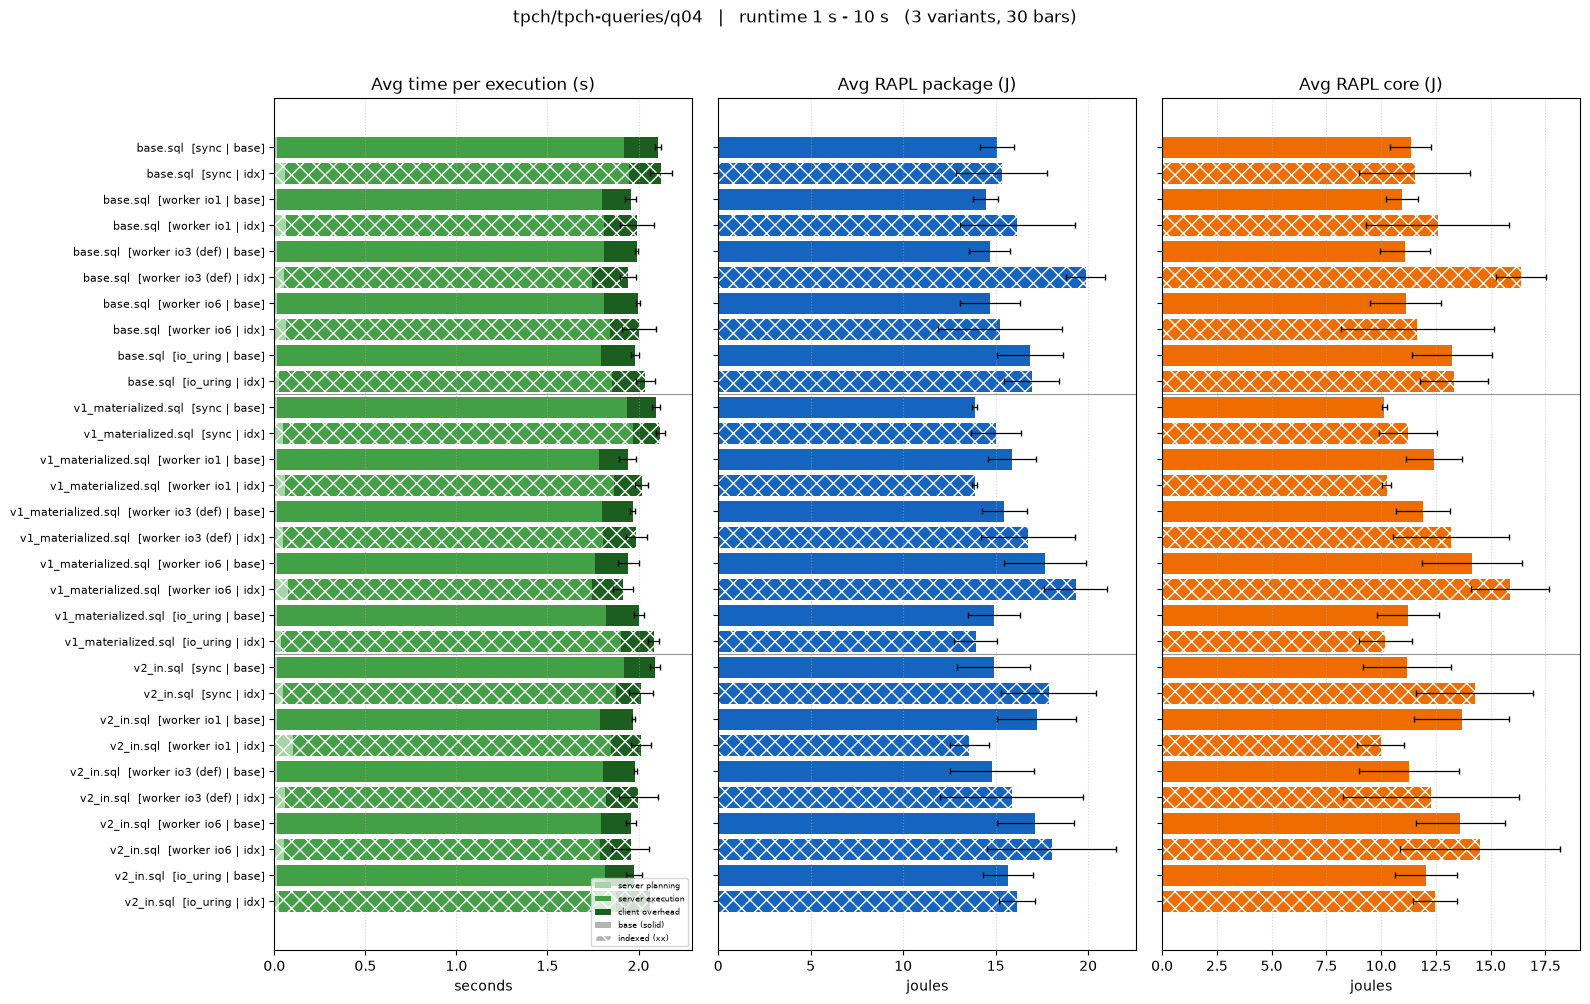

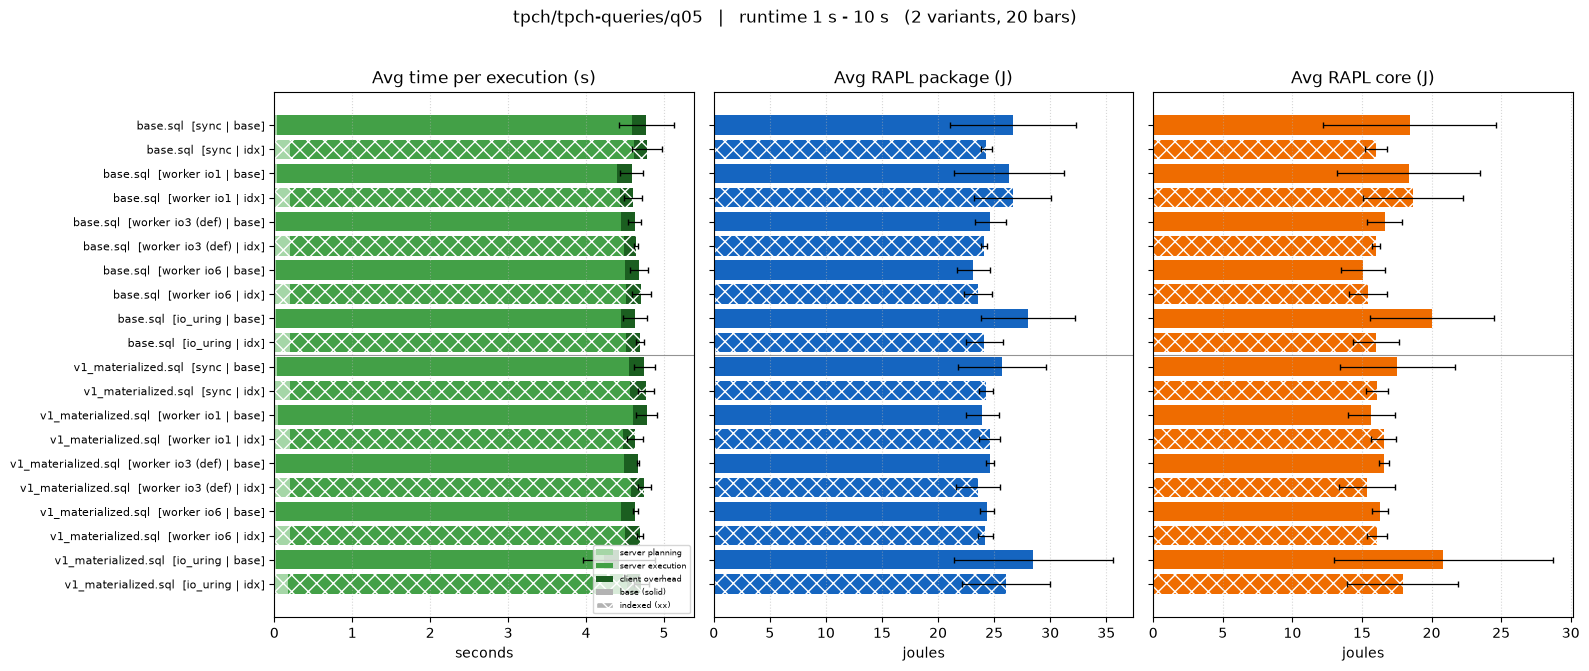

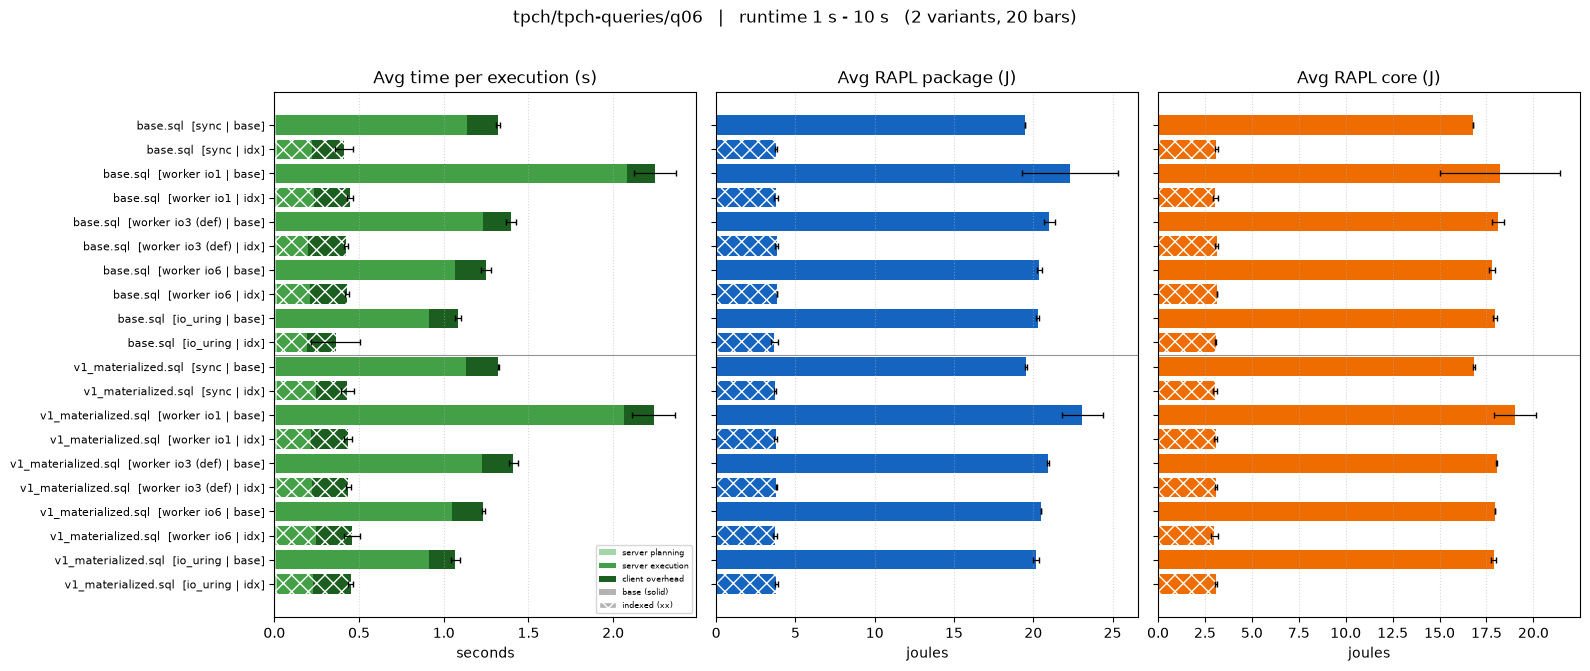

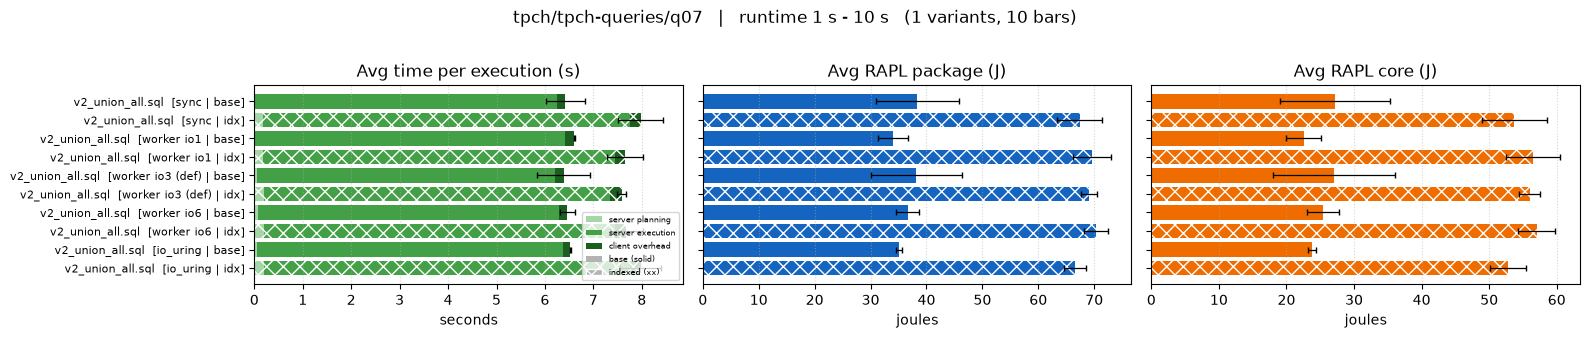

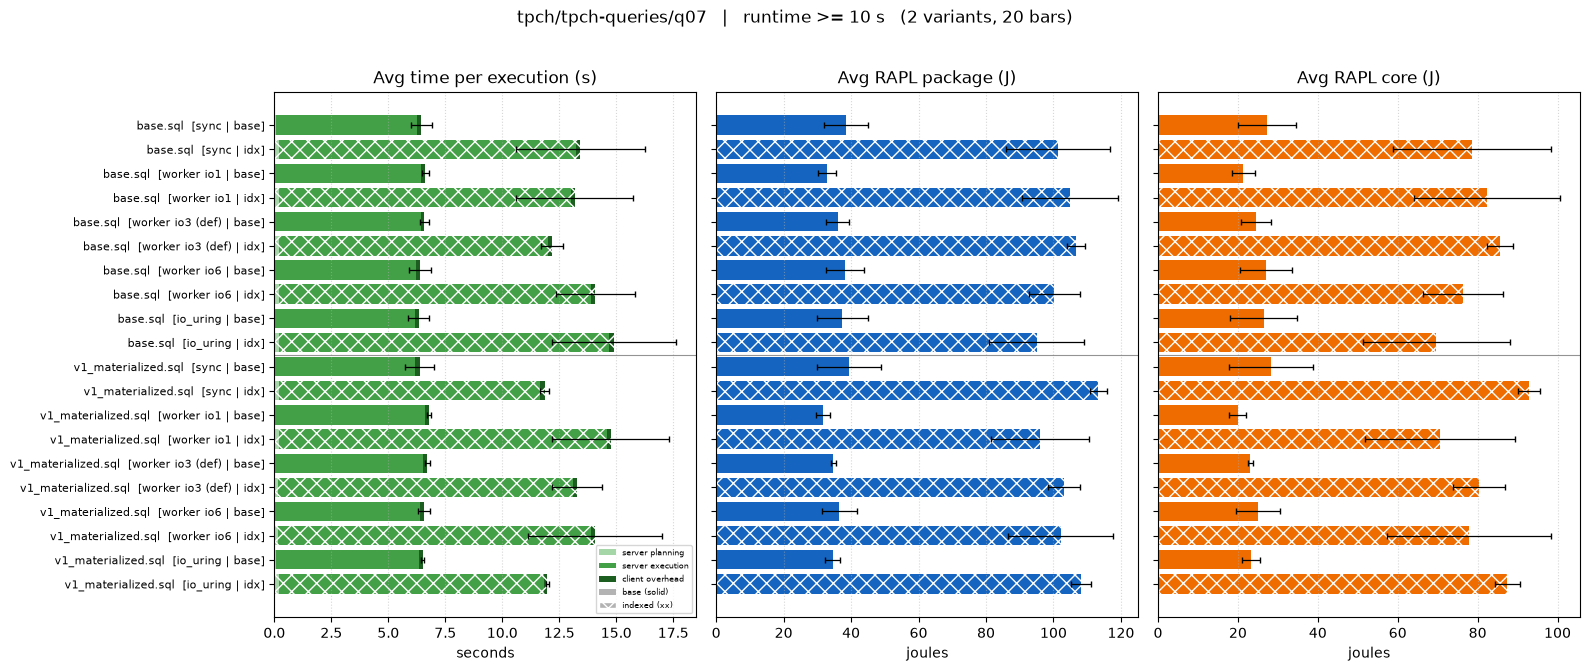

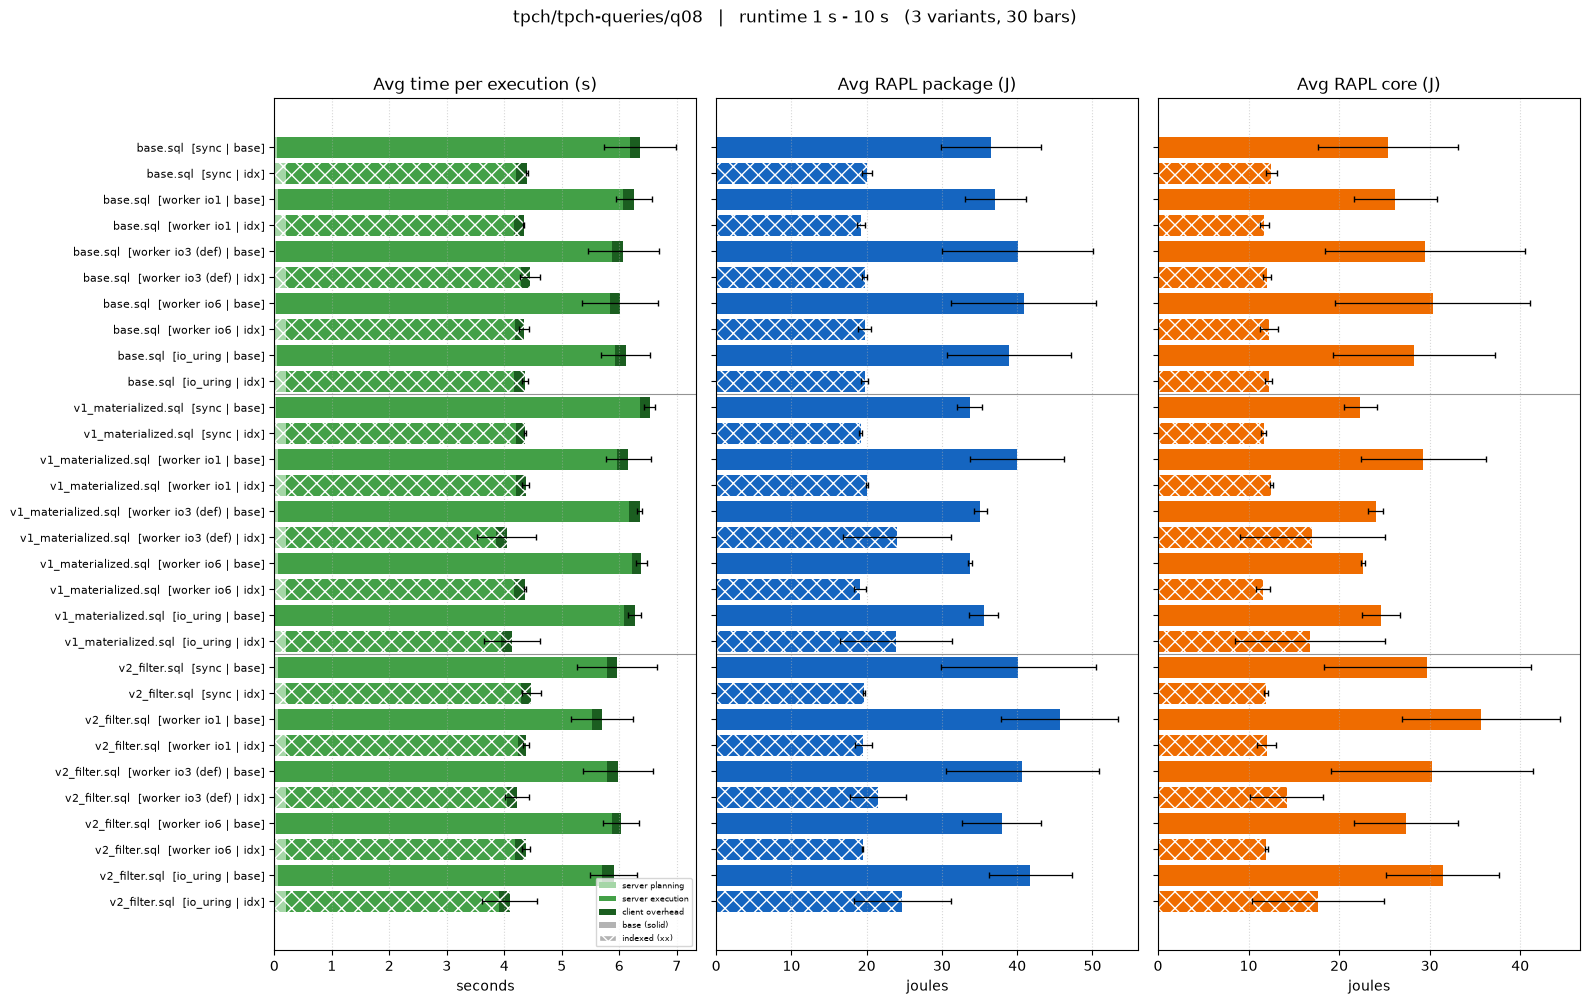

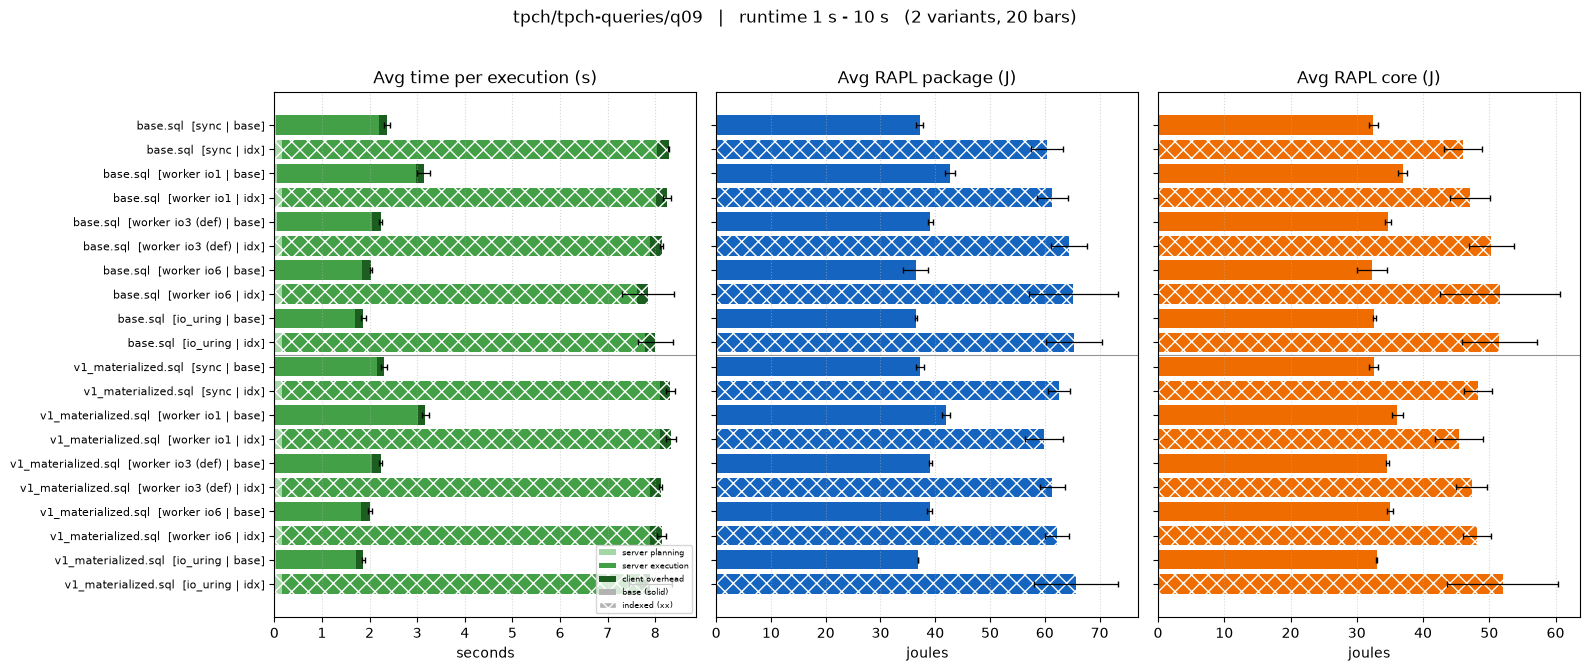

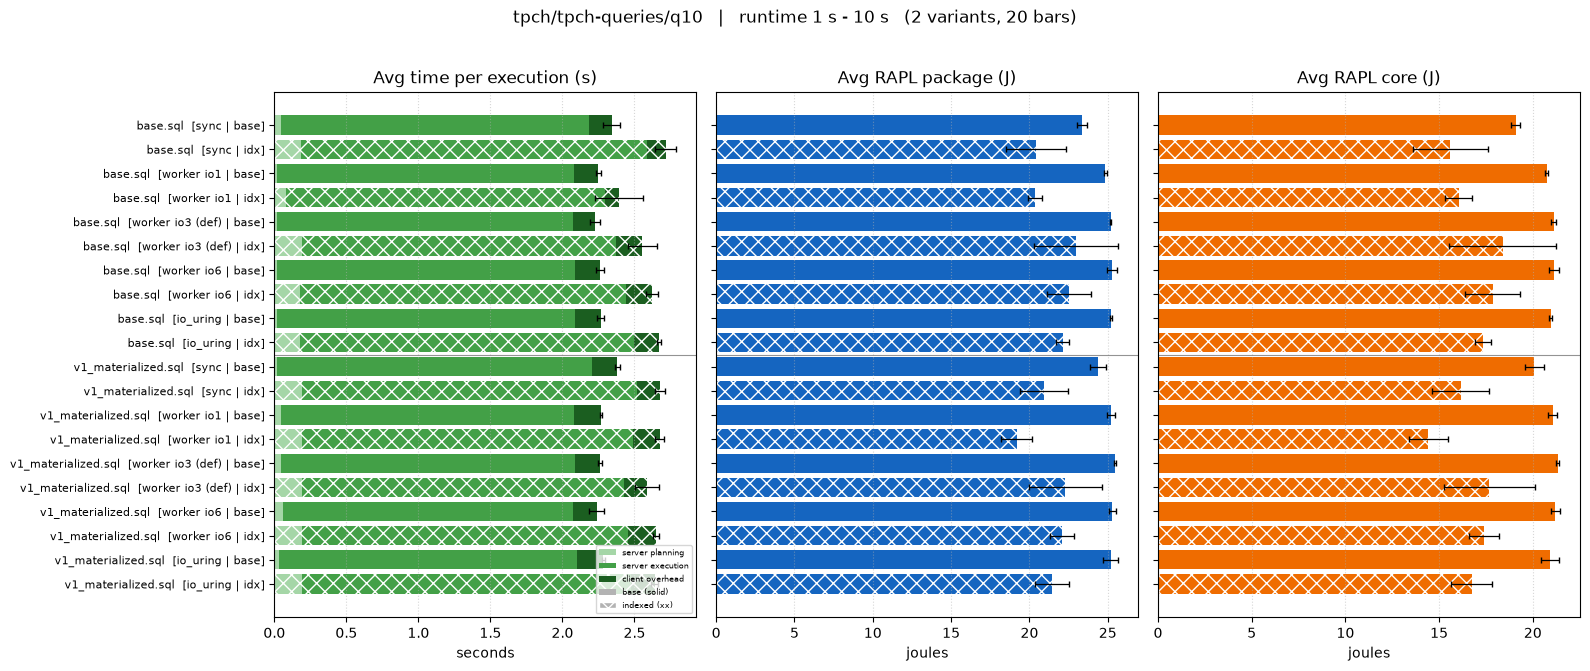

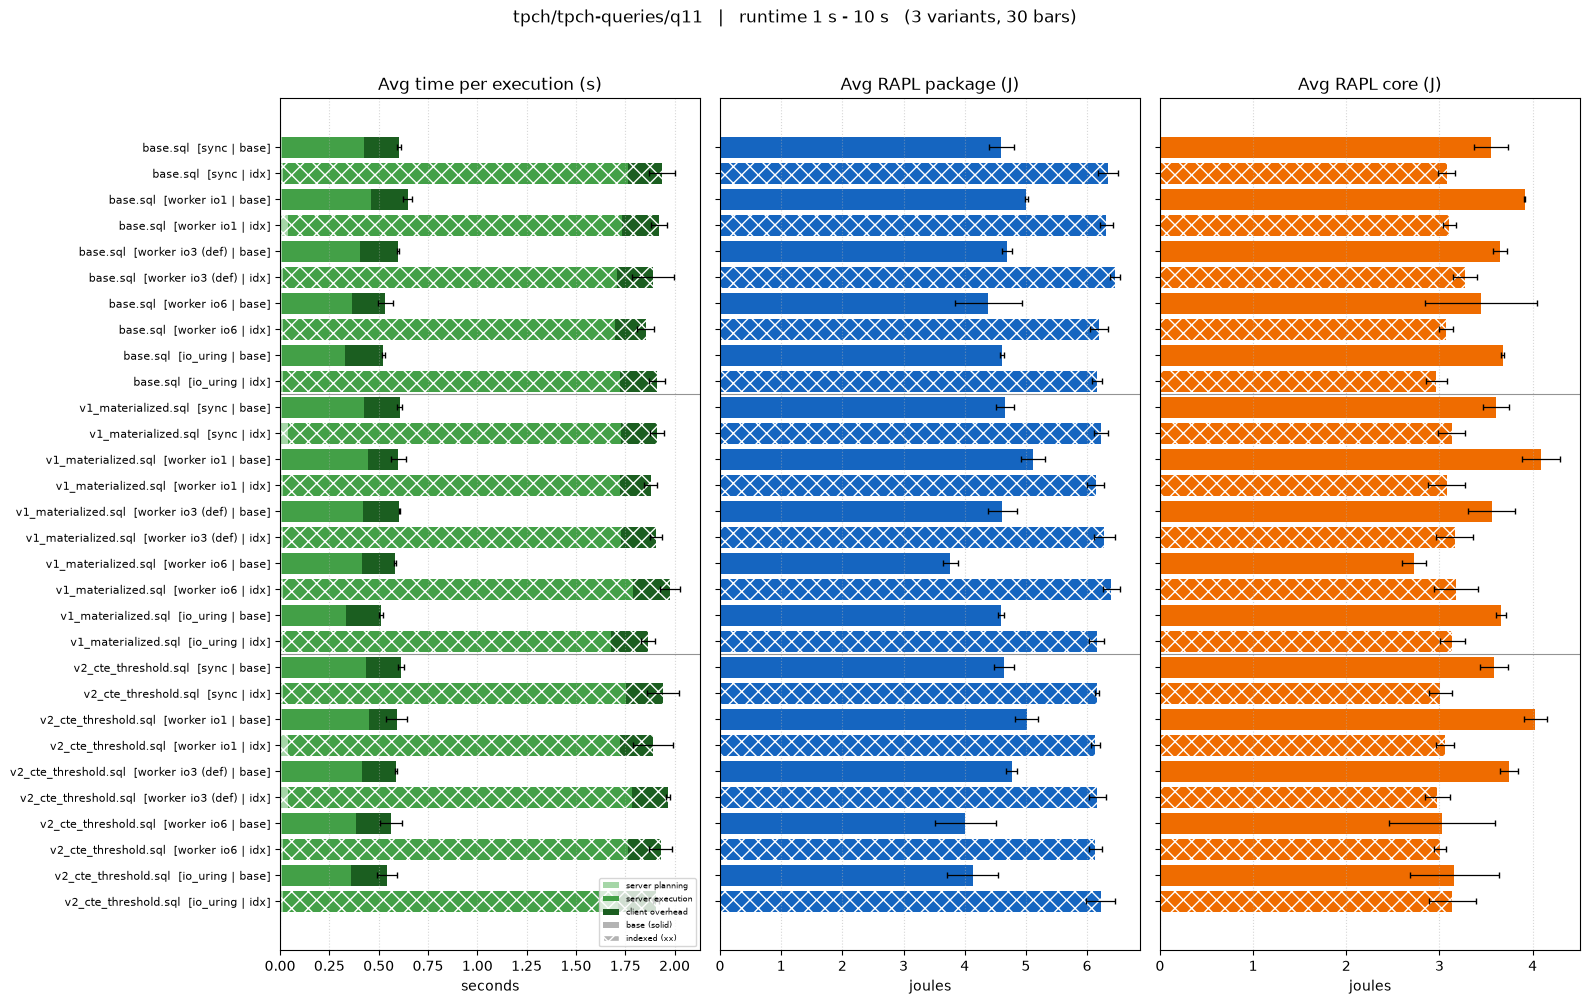

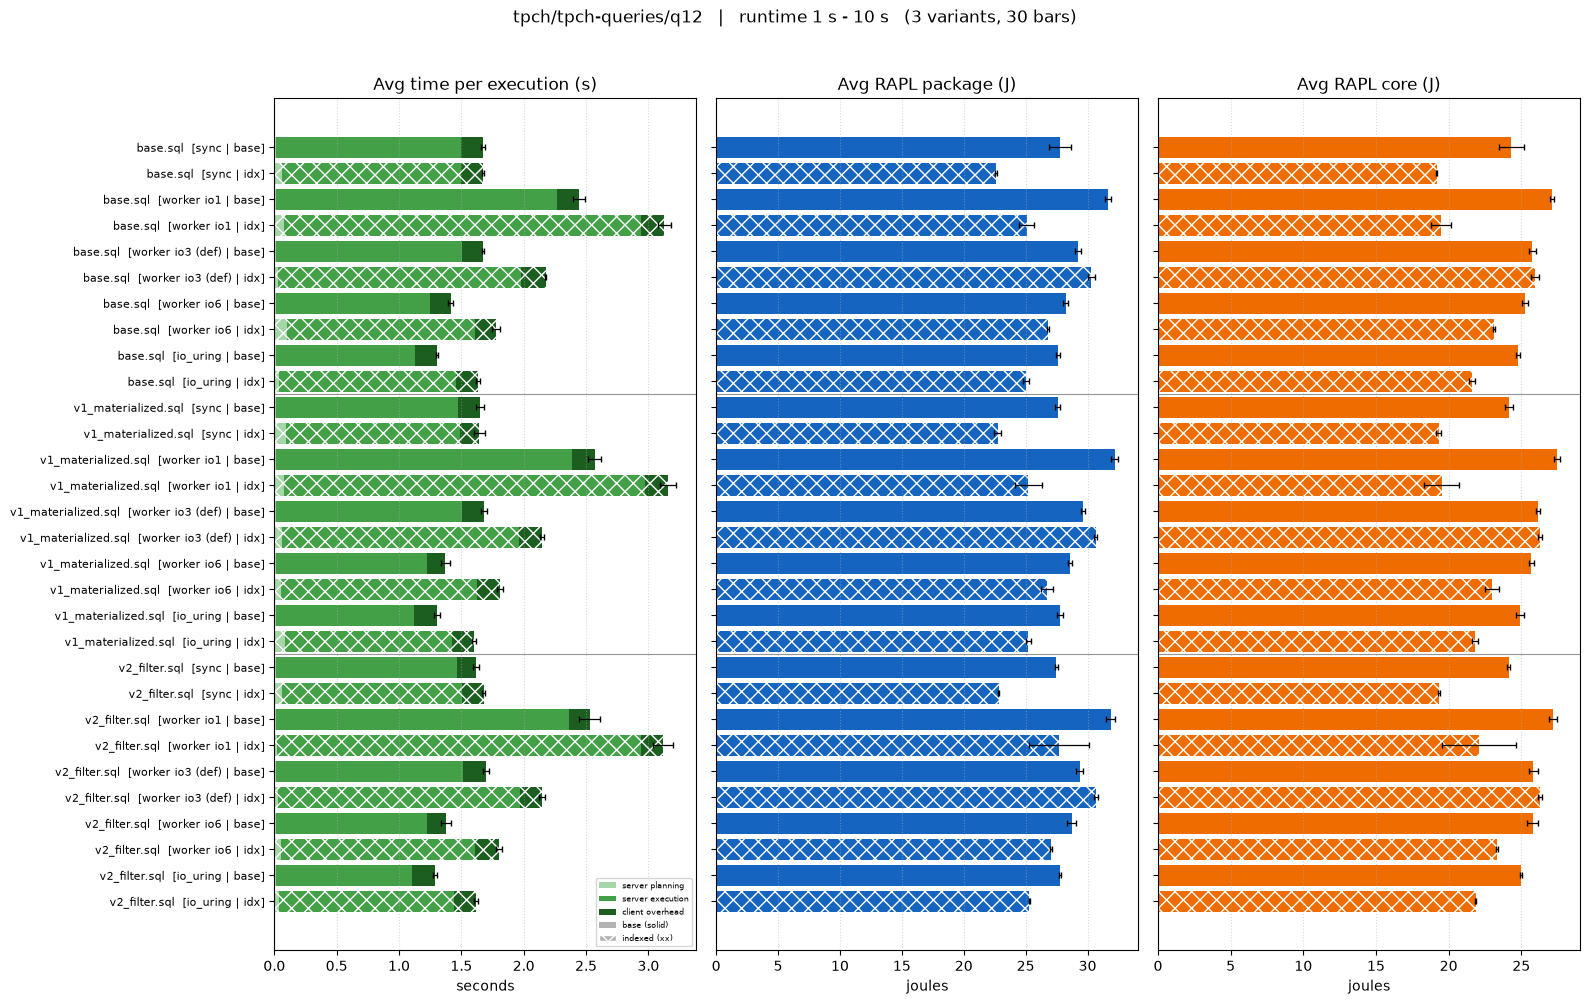

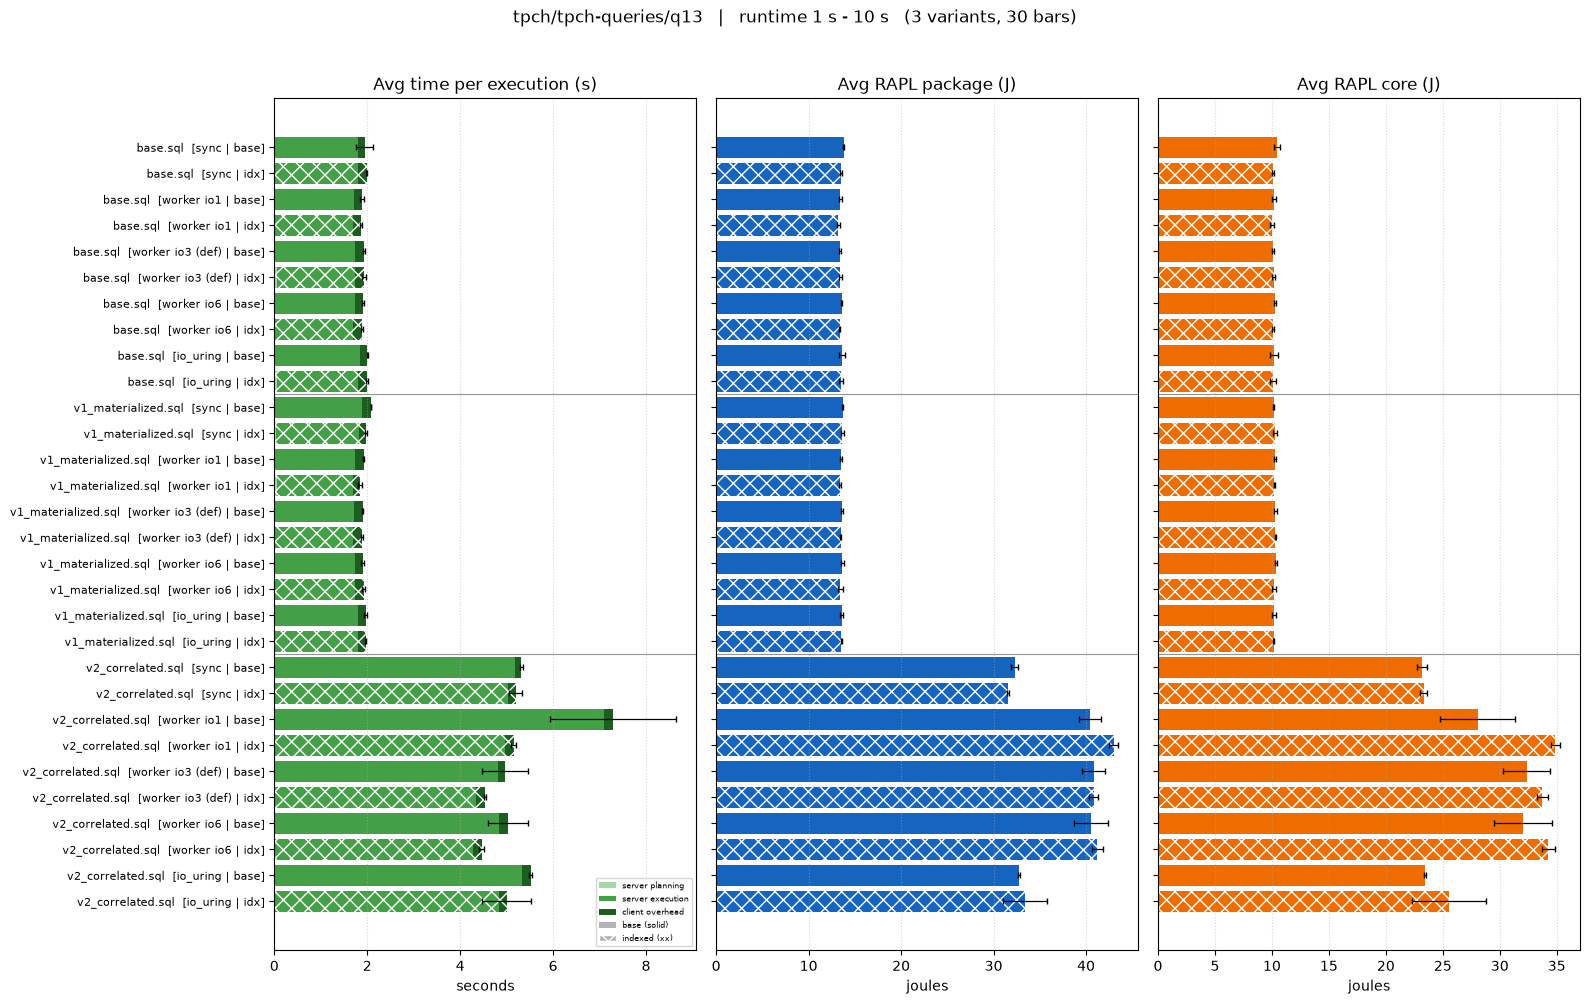

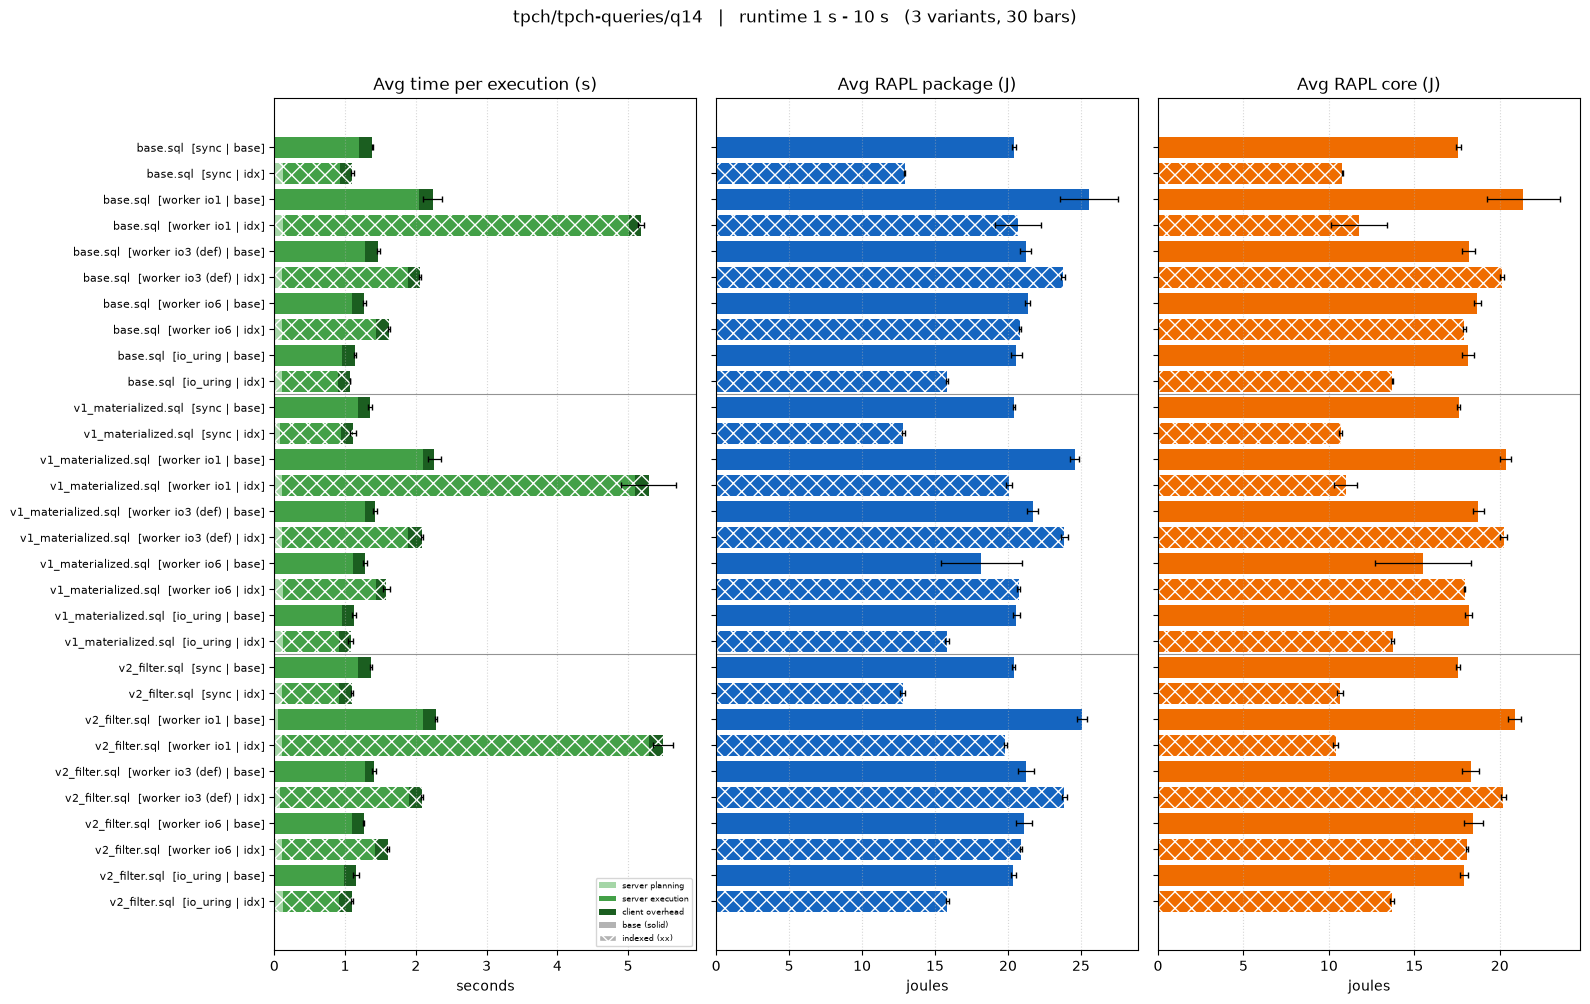

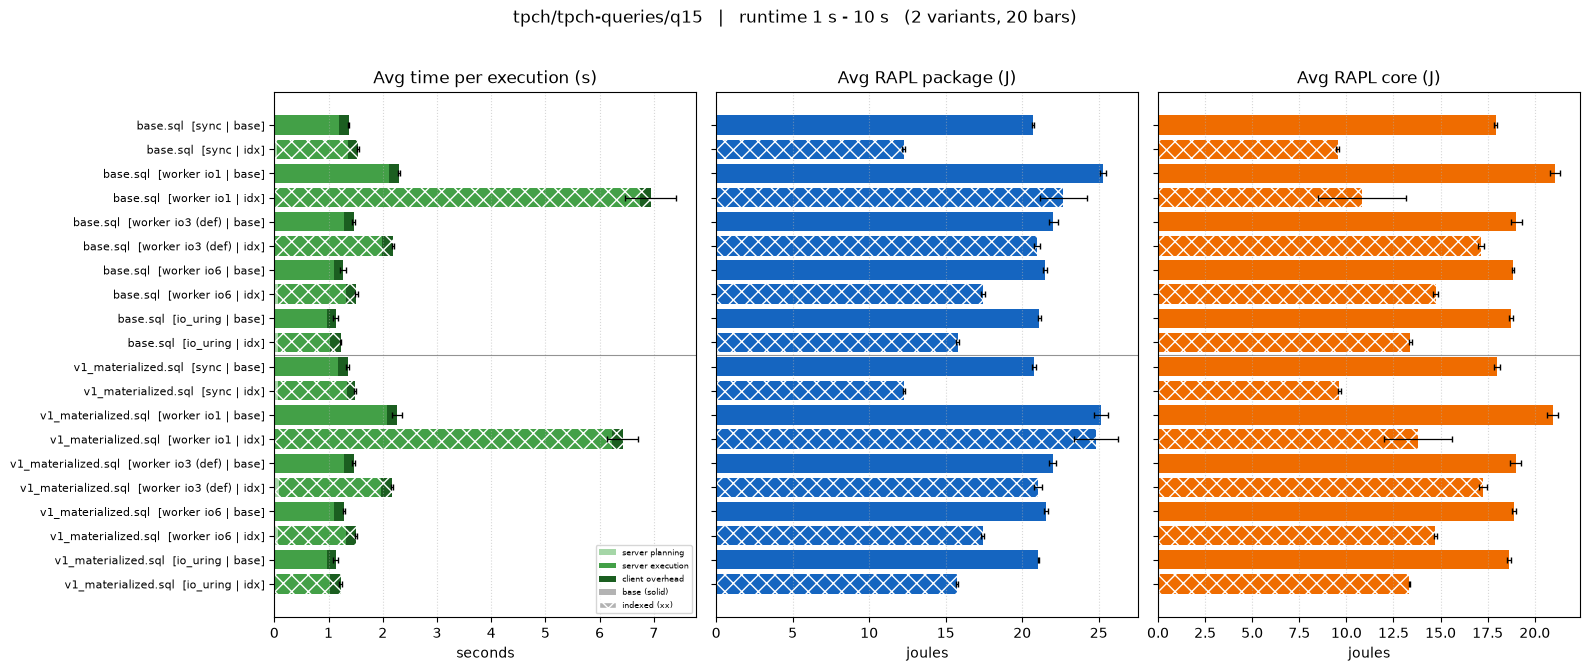

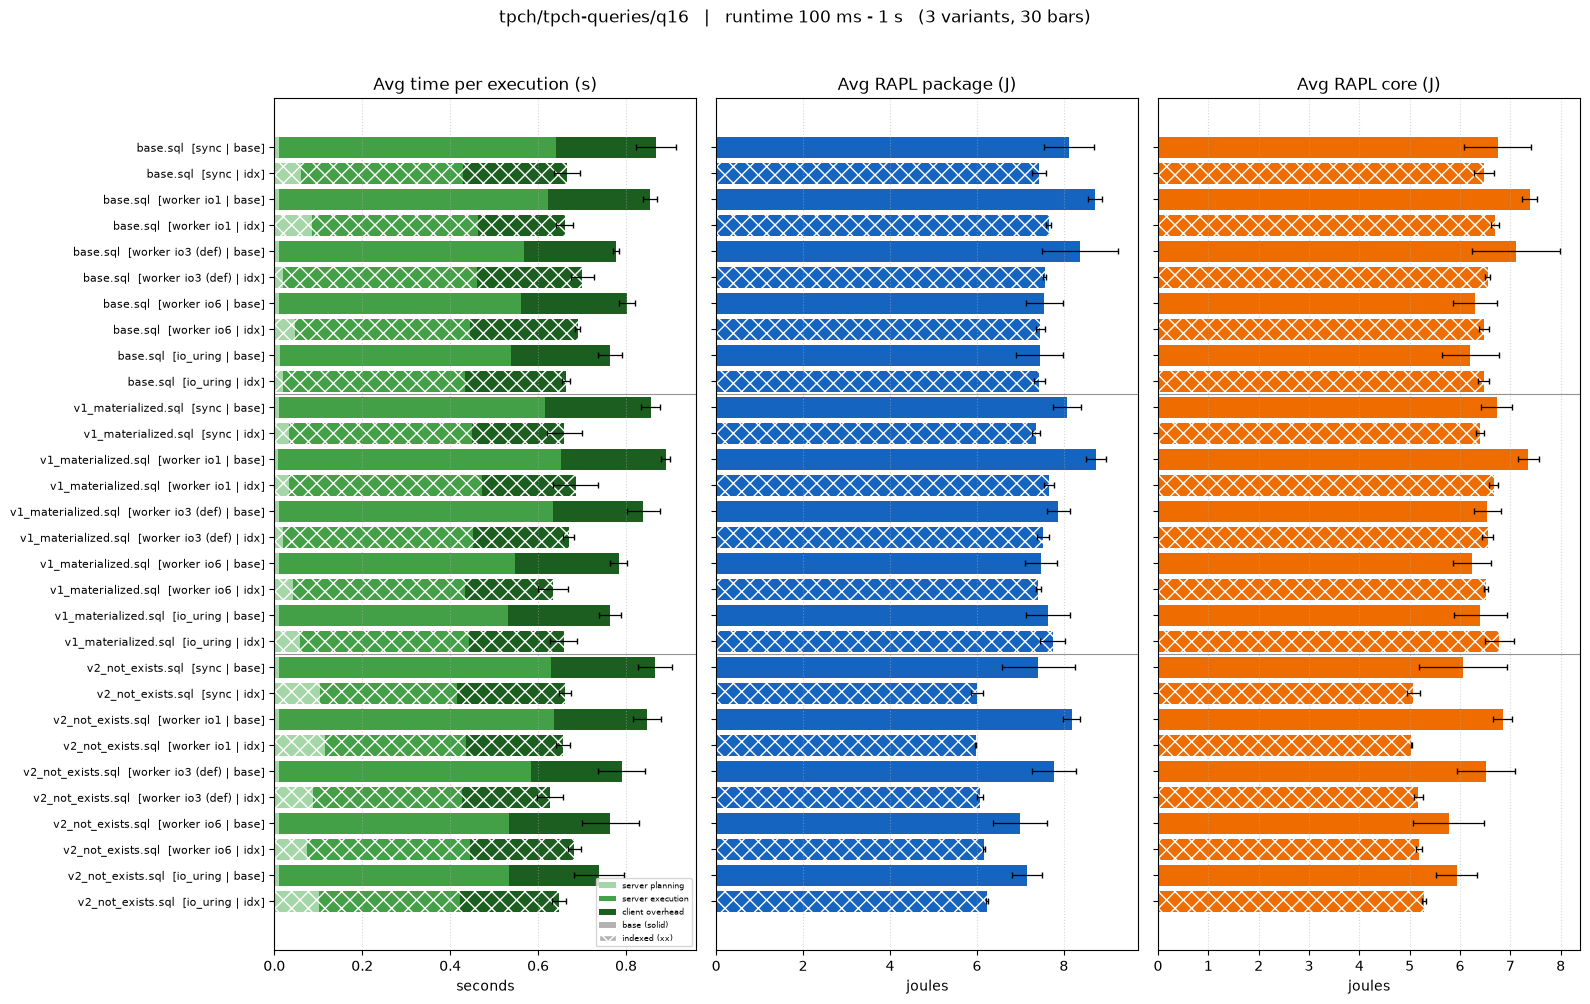

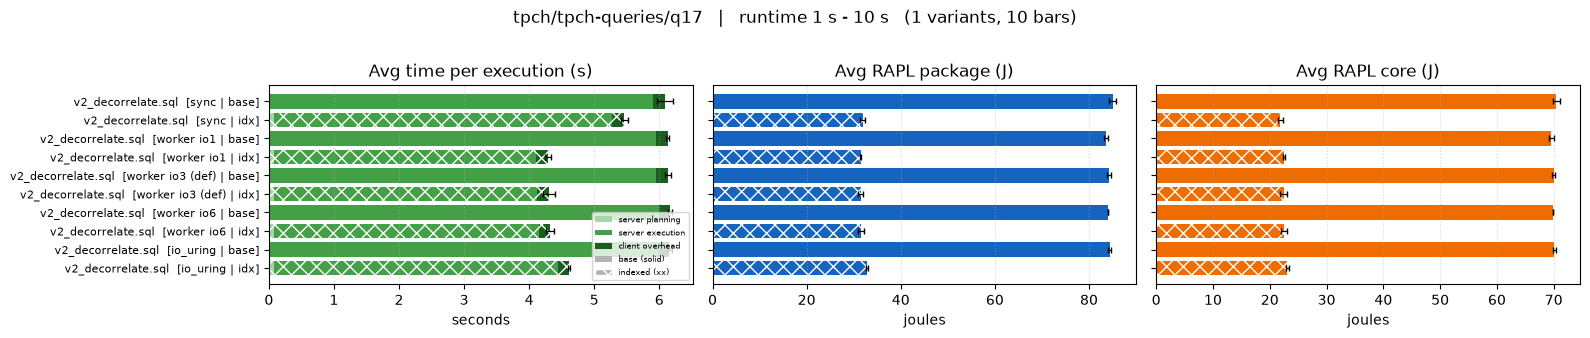

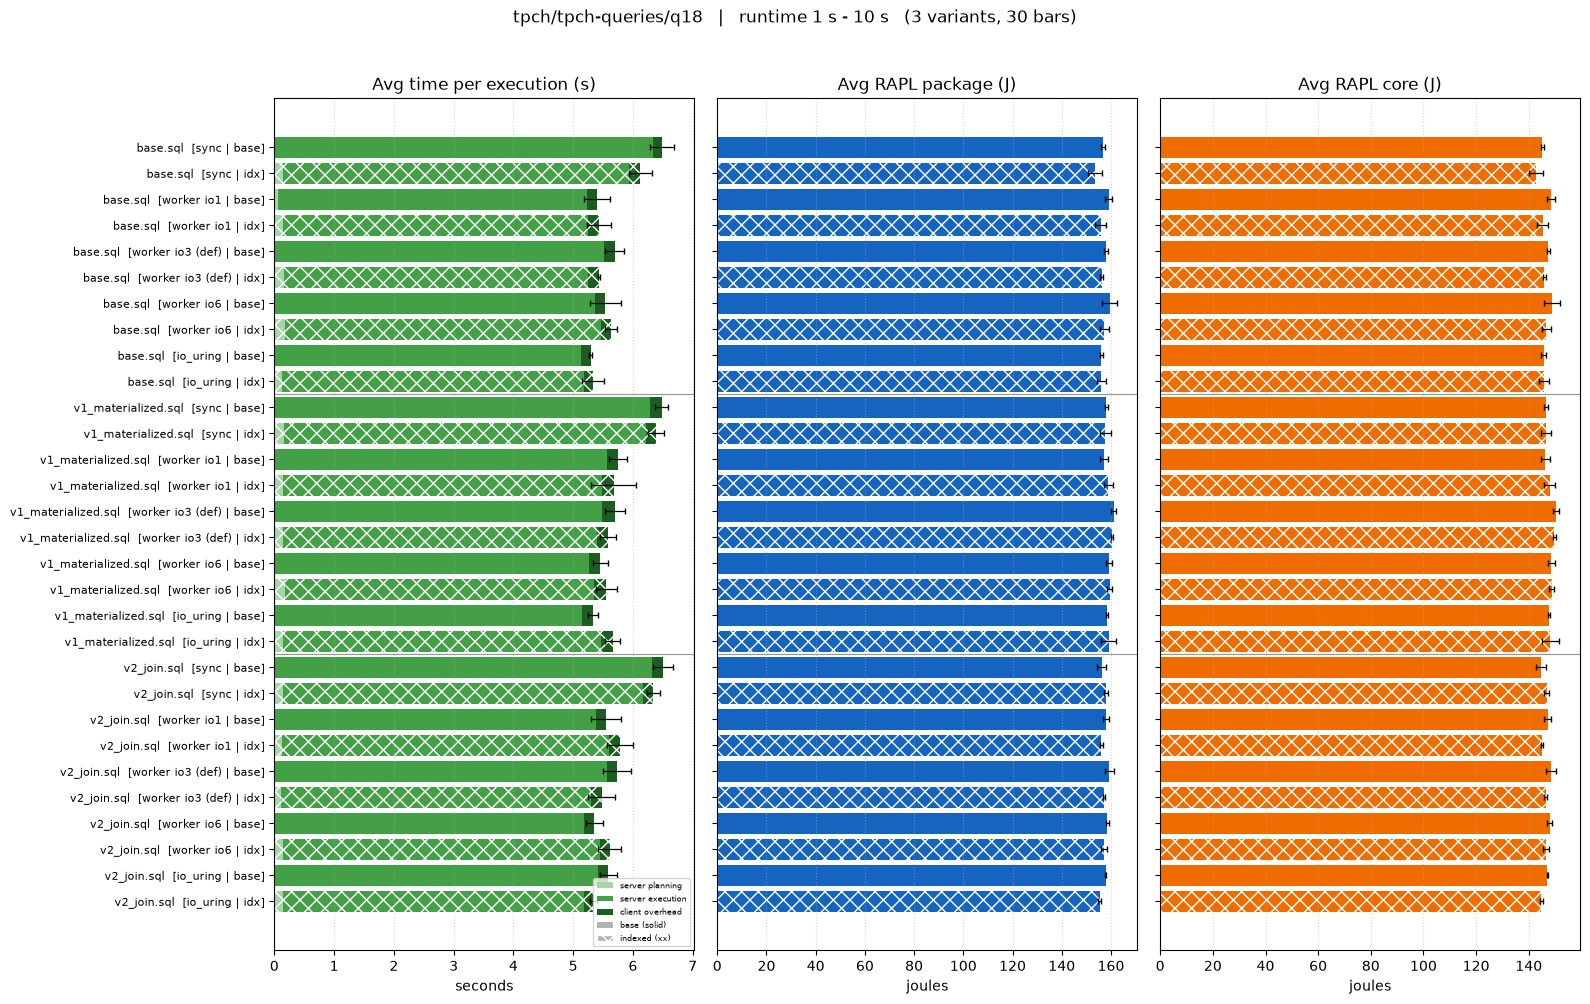

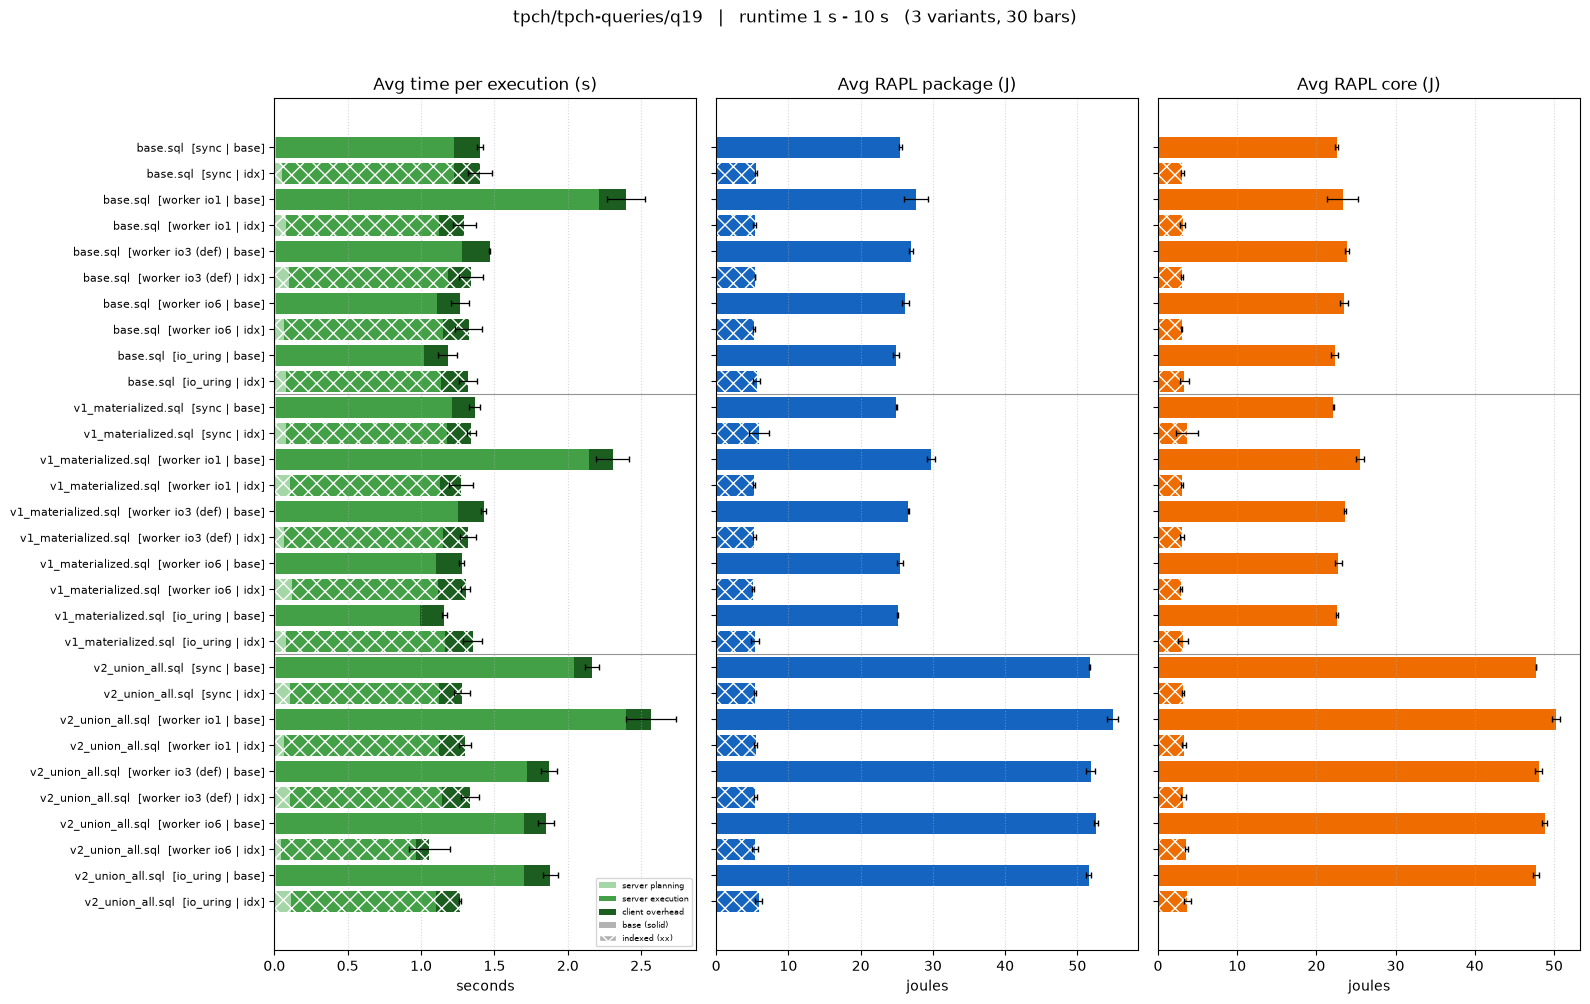

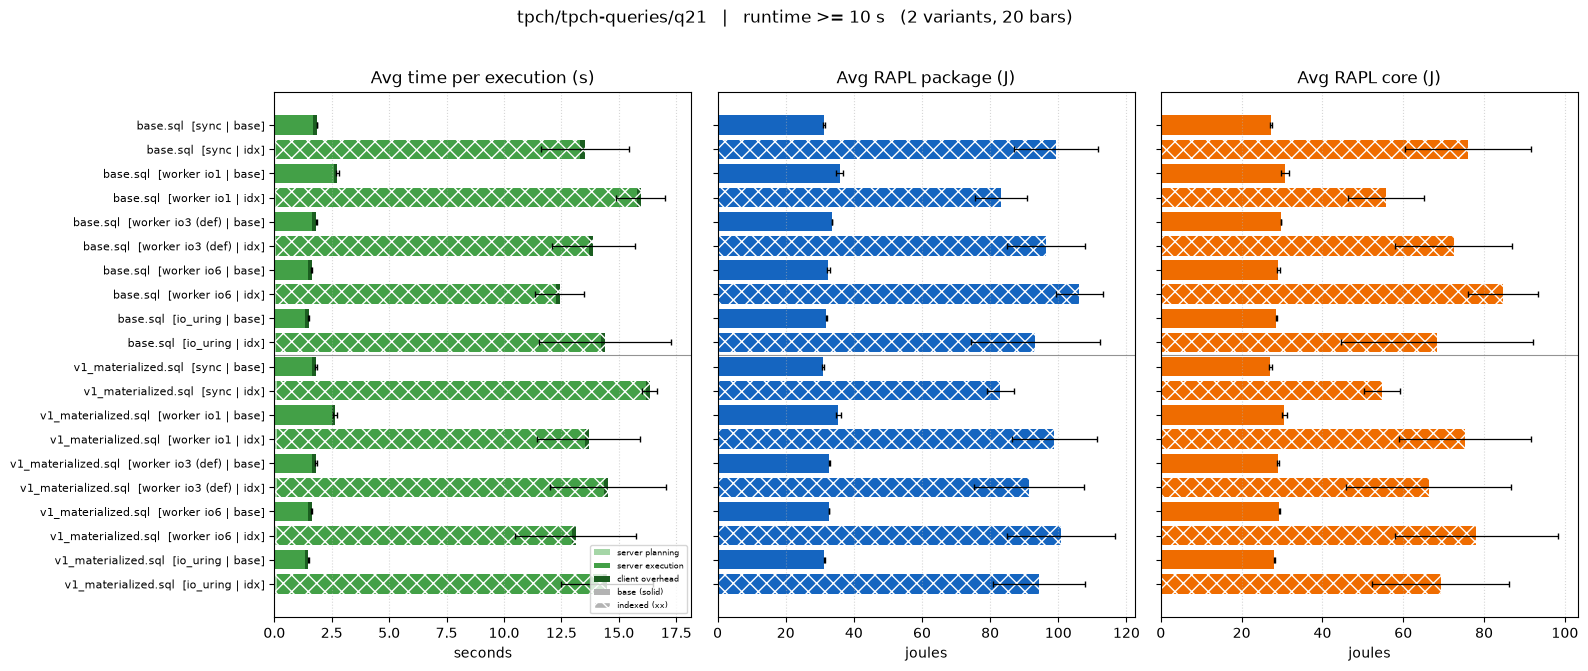

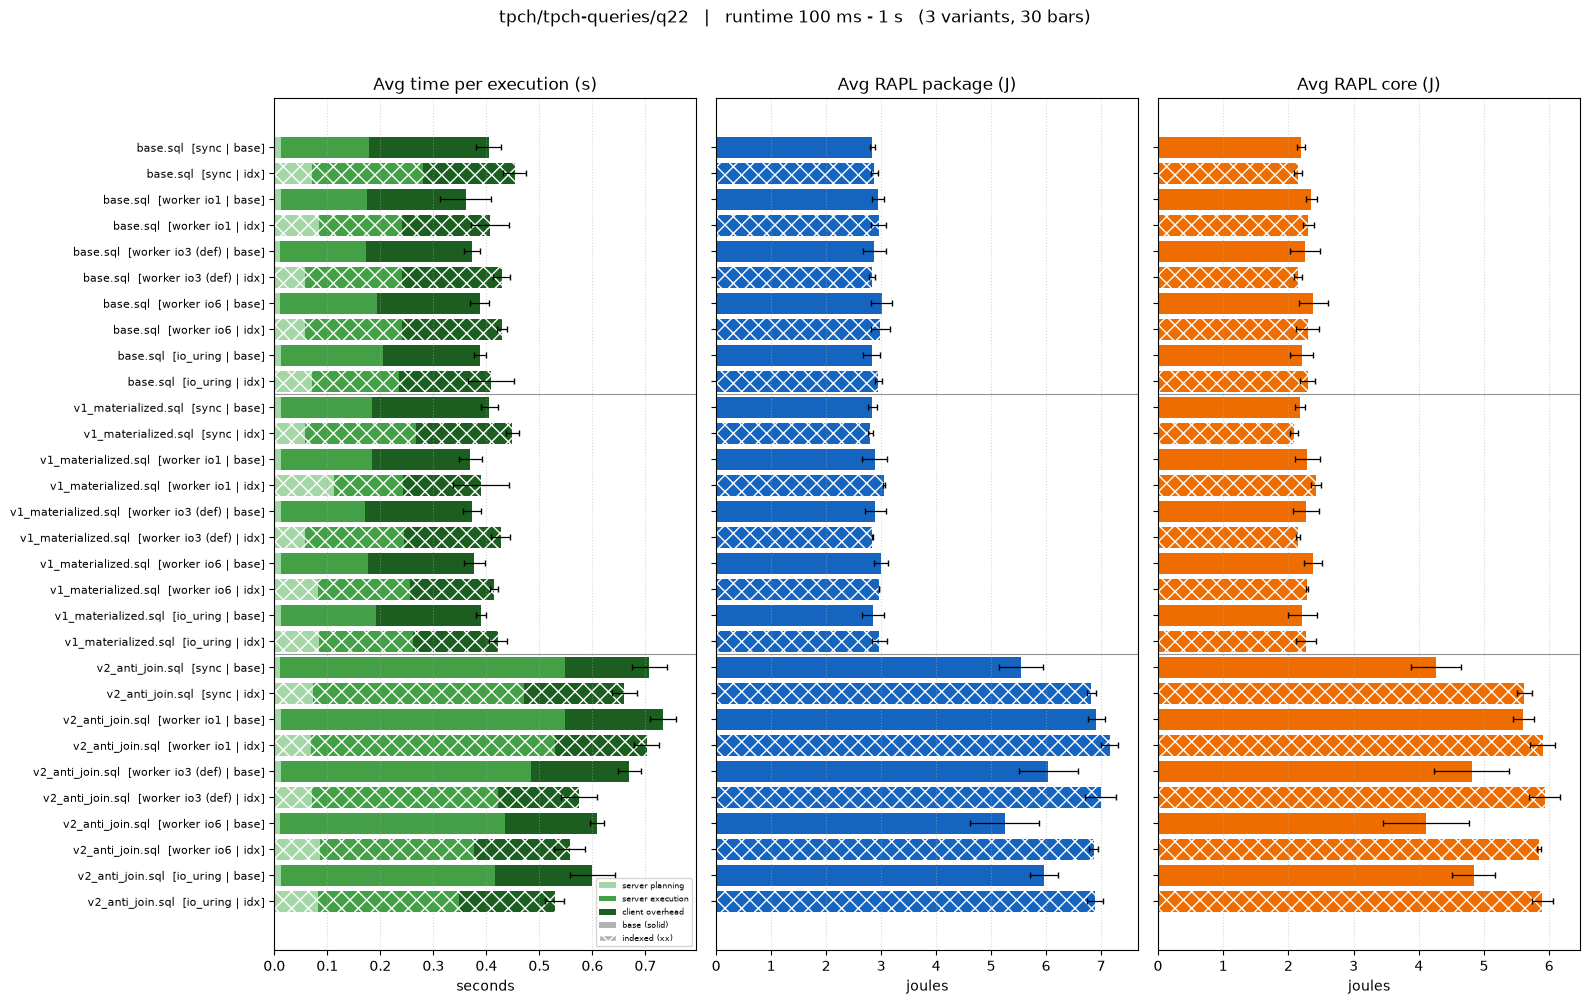

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

GROUPS = None                      # query folders to draw; None = all
RUNTIME_BINS = [0.0, 0.1, 1.0, 10.0]   # bin START values in seconds
BIN_STAT = "max"                   # "max" | "median" | "min" | "mean"
MAX_FIGURES = 250

COMPONENTS = [
    ("plan_s", "#a5d6a7", "server planning"),
    ("exec_s", "#43a047", "server execution"),
    ("overhead_s", "#1b5e20", "client overhead"),
]
IDX_HATCH = "xx"
edges = list(RUNTIME_BINS) + [np.inf]


def fmt_t(s):
    return f"{s * 1000:g} ms" if s < 1 else f"{s:g} s"


def bin_name(i):
    lo, hi = edges[i], edges[i + 1]
    return f">= {fmt_t(lo)}" if np.isinf(hi) else f"{fmt_t(lo)} - {fmt_t(hi)}"


all_groups = sorted(data["group"].dropna().unique())
groups = all_groups if GROUPS is None else [g for g in all_groups if g in GROUPS]

qrep = data.groupby("query")["avg_time_s"].agg(BIN_STAT)
qbin = pd.Series(np.digitize(qrep.to_numpy(), edges[1:], right=False),
                 index=qrep.index)
qbin[qrep.isna()] = -1
dq = data.copy()
dq["_bin"] = dq["query"].map(qbin)
dq["_idx_ord"] = (dq["index_status"] == "idx").astype(int)
dq["plab"] = (dq["sql_file"] + "  [" + dq["plabel"]
              + " | " + dq["index_status"] + "]")

tasks = []
for group in groups:
    gb = dq.loc[dq["group"] == group, "_bin"]
    for i in sorted(b for b in gb.dropna().unique() if b >= 0):
        tasks.append((group, int(i)))
print(f"{len(groups)} query folder(s) -> {len(tasks)} figures")
if len(tasks) > MAX_FIGURES:
    print(f"capping to {MAX_FIGURES}")
    tasks = tasks[:MAX_FIGURES]


def hatch_idx(container, is_idx):
    for bar, ix in zip(container, is_idx):
        if ix:
            bar.set_hatch(IDX_HATCH)
            bar.set_edgecolor("white")
            bar.set_linewidth(0.0)


for group, i in tasks:
    g = dq[(dq["group"] == group) & (dq["_bin"] == i)].copy()
    g = g.sort_values(["sql_file", "pval", "_idx_ord"])
    y = np.arange(len(g))
    is_idx = (g["index_status"] == "idx").to_numpy()
    height = max(1.8, len(g) * 0.34)
    fig, axes = plt.subplots(1, 3, figsize=(16, height), sharey=True)

    ax = axes[0]
    left = np.zeros(len(g))
    for col, colour, _ in COMPONENTS:
        hatch_idx(ax.barh(y, g[col].fillna(0).to_numpy(dtype=float),
                          left=left, color=colour), is_idx)
        left += g[col].fillna(0).to_numpy(dtype=float)
    std = g["time_std"].to_numpy(dtype=float)
    ok = ~np.isnan(std)
    if ok.any():
        ax.errorbar(left[ok], y[ok], xerr=std[ok], fmt="none",
                    ecolor="black", elinewidth=0.9, capsize=2)
    ax.set_title("Avg time per execution (s)"); ax.set_xlabel("seconds")
    handles = [Patch(facecolor=c, label=l) for _, c, l in COMPONENTS]
    handles += [Patch(facecolor="0.7", label="base (solid)"),
                Patch(facecolor="0.7", hatch=IDX_HATCH, edgecolor="white",
                      label="indexed (xx)")]
    ax.legend(handles=handles, fontsize=6, loc="lower right")

    for ax, col, scol, colour, title in (
        (axes[1], "avg_pkg_j", "pkg_j_std", "#1565c0", "Avg RAPL package (J)"),
        (axes[2], "avg_core_j", "core_j_std", "#ef6c00", "Avg RAPL core (J)"),
    ):
        vals = g[col].to_numpy(dtype=float)
        hatch_idx(ax.barh(y, np.nan_to_num(vals), color=colour), is_idx)
        estd = g[scol].to_numpy(dtype=float)
        eok = ~np.isnan(estd) & ~np.isnan(vals)
        if eok.any():
            ax.errorbar(vals[eok], y[eok], xerr=estd[eok], fmt="none",
                        ecolor="black", elinewidth=0.9, capsize=2)
        ax.set_title(title); ax.set_xlabel("joules")

    sql = g["sql_file"].to_numpy()
    bounds = [k - 0.5 for k in range(1, len(g)) if sql[k] != sql[k - 1]]
    for ax in axes:
        ax.grid(axis="x", linestyle=":", alpha=0.5)
        for yb in bounds:
            ax.axhline(yb, color="0.4", lw=0.8, alpha=0.7)
    axes[0].set_yticks(y); axes[0].set_yticklabels(g["plab"], fontsize=8)
    axes[0].invert_yaxis()
    fig.suptitle(f"{group}   |   runtime {bin_name(i)}   "
                 f"({g['sql_file'].nunique()} variants, {len(g)} bars)", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

## 4. I/O method — sync vs worker(N) vs io_uring

`io_method` (PostgreSQL 18) chooses how asynchronous reads are executed: `sync`
(no async), `worker` with a pool of `io_workers` (1 / 3 / 6 here), or `io_uring`
(kernel async). It only matters when reads hit disk, so these are **cold** runs.
This compares the methods head-to-head on total and per-query cold runtime and
energy, and counts how many queries each method wins.

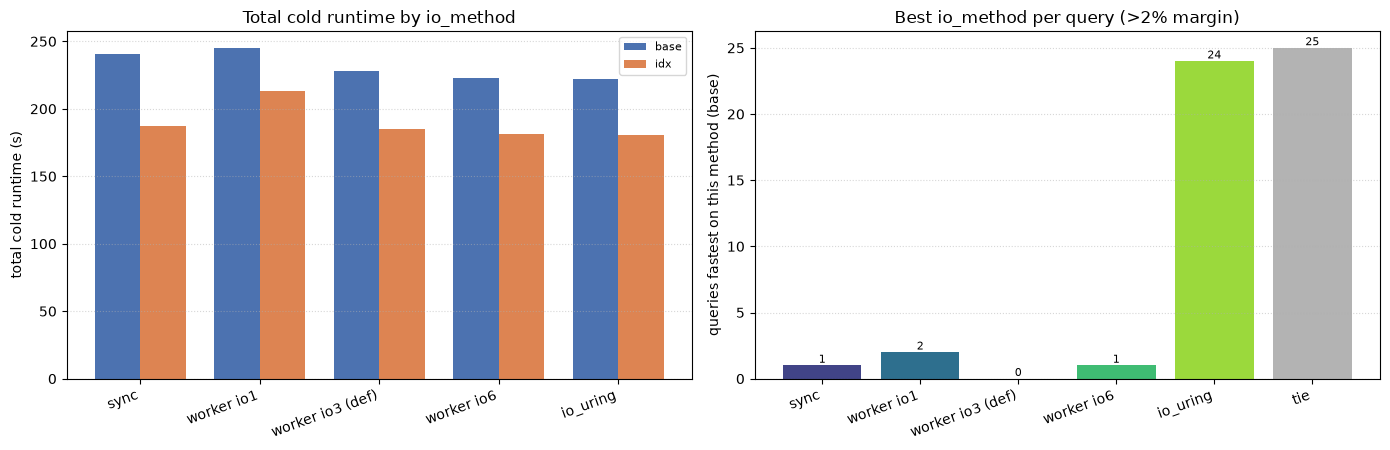

Total cold runtime / energy by io_method:
index_status  pval  total_runtime_s  total_energy_j           method
        base     0            240.3          2717.5             sync
        base     1            245.2          2856.5       worker io1
        base     2            228.0          2811.6 worker io3 (def)
        base     3            223.2          2790.1       worker io6
        base     4            221.7          2779.3         io_uring
         idx     0            187.4          1750.9             sync
         idx     1            213.0          1810.1       worker io1
         idx     2            184.8          1864.1 worker io3 (def)
         idx     3            181.2          1844.5       worker io6
         idx     4            180.9          1796.1         io_uring


In [4]:
# categorical: pval is the method index, p_label the method name
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

tot = data.groupby(["index_status", "pval"]).agg(
    total_runtime_s=("avg_time_s", "sum"),
    total_energy_j=("avg_pkg_j", "sum")).reset_index()
labels = [p_label(v) for v in PVALS]
x = np.arange(len(PVALS)); w = 0.38
for k, ix in enumerate(IDX_ALL):
    t = tot[tot["index_status"] == ix].set_index("pval").reindex(PVALS)
    axes[0].bar(x + (k - 0.5) * w, t["total_runtime_s"].values, w,
                color=colours[ix], label=ix)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=20, ha="right")
axes[0].set_ylabel("total cold runtime (s)")
axes[0].set_title("Total cold runtime by io_method")
axes[0].grid(axis="y", linestyle=":", alpha=0.5); axes[0].legend(fontsize=8)

# per-query best method (base): count wins with a small margin
base = data[data["index_status"] == "base"]
rt = base.pivot_table(index="qid", columns="pval", values="avg_time_s").reindex(columns=PVALS).dropna(how="any")
if not rt.empty:
    arr = rt.to_numpy(); order = np.argsort(arr, axis=1)
    rows = np.arange(len(arr))
    best = arr[rows, order[:, 0]]; runner = arr[rows, order[:, 1]]
    win = np.where(runner > best * 1.02, np.array(PVALS)[order[:, 0]].astype(object), "tie")
    wins = pd.Series(win, index=rt.index).value_counts()
    vals = [int(wins.get(m, 0)) for m in PVALS] + [int(wins.get("tie", 0))]
    axes[1].bar(range(len(PVALS) + 1), vals,
                color=list(plt.cm.viridis(np.linspace(0.2, 0.85, len(PVALS)))) + [(0.7, 0.7, 0.7, 1)])
    axes[1].set_xticks(range(len(PVALS) + 1))
    axes[1].set_xticklabels(labels + ["tie"], rotation=20, ha="right")
    for i, v in enumerate(vals):
        axes[1].text(i, v, str(v), ha="center", va="bottom", fontsize=8)
    axes[1].set_ylabel("queries fastest on this method (base)")
    axes[1].set_title("Best io_method per query (>2% margin)")
    axes[1].grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()

print("Total cold runtime / energy by io_method:")
print(tot.assign(method=tot["pval"].map(p_label)).round(1).to_string(index=False))

## 5. Runtime & energy vs io_method — where does tuning pay off?

For each query, runtime and package energy are taken relative to their value at
the **smallest** io_method setting, so `1.0` = same as the smallest and `< 1` =
faster / leaner. The heavy line is the median over queries; the summed totals per
setting say which value is best **overall**.

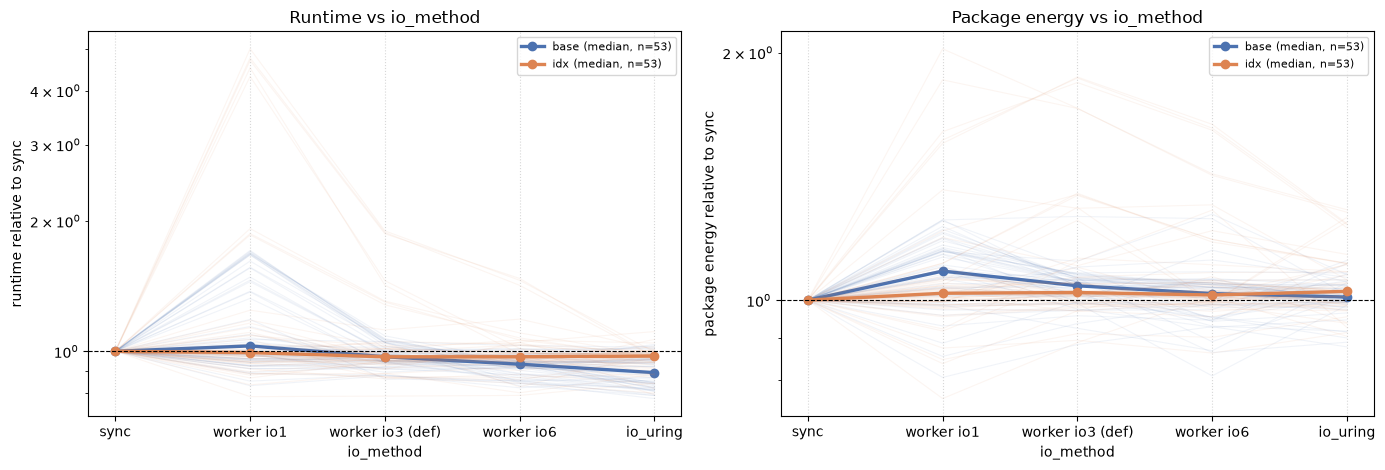

Total runtime / energy across the common query set, by io_method:
index_status  pval  total_runtime_s  total_energy_j  queries
        base     0            240.3          2717.5       53
        base     1            245.2          2856.5       53
        base     2            228.0          2811.6       53
        base     3            223.2          2790.1       53
        base     4            221.7          2779.3       53
         idx     0            187.4          1750.9       53
         idx     1            213.0          1810.1       53
         idx     2            184.8          1864.1       53
         idx     3            181.2          1844.5       53
         idx     4            180.9          1796.1       53
  [base] fastest total: io_uring  |  lowest energy: sync
  [idx] fastest total: io_uring  |  lowest energy: sync


In [5]:
def relative(metric, ix):
    # use only the values this variant covers broadly, so an incomplete point
    # (e.g. one query at the largest setting) doesn't collapse the whole line
    sub = data[data["index_status"] == ix]
    cov = sub.groupby("pval")["qid"].nunique()
    good = [m for m in PVALS if cov.get(m, 0) >= 0.5 * cov.max()]
    piv = sub.pivot_table(index="qid", columns="pval", values=metric).reindex(columns=good)
    piv = piv.dropna(how="any")
    rel = piv.div(piv[good[0]], axis=0) if not piv.empty else piv
    return good, piv, rel


fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, metric, nice in ((axes[0], "avg_time_s", "runtime"),
                         (axes[1], "avg_pkg_j", "package energy")):
    for ix in IDX_ALL:
        good, piv, rel = relative(metric, ix)
        if rel.empty:
            continue
        for _, row in rel.iterrows():
            ax.plot(good, row.values, color=colours[ix], alpha=0.08, lw=0.8)
        ax.plot(good, rel.median().values, color=colours[ix], marker="o",
                lw=2.4, label=f"{ix} (median, n={len(rel)})")
    ax.axhline(1.0, color="k", lw=0.8, ls="--")
    ax.set_yscale("log")
    set_xaxis(ax)
    ax.set_ylabel(f"{nice} relative to {p_label(PVALS[0])}")
    ax.set_title(f"{nice.capitalize()} vs io_method"); ax.grid(linestyle=":", alpha=0.5)
    ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

tot = data.groupby(["index_status", "pval"]).agg(
    total_runtime_s=("avg_time_s", "sum"),
    total_energy_j=("avg_pkg_j", "sum"),
    queries=("qid", "nunique")).reset_index()
print("Total runtime / energy across the common query set, by io_method:")
print(tot.round(1).to_string(index=False))
for ix in IDX_ALL:
    t = tot[tot["index_status"] == ix].set_index("pval")
    bt = t["total_runtime_s"].idxmin(); be = t["total_energy_j"].idxmin()
    print(f"  [{ix}] fastest total: {p_label(bt)}  |  lowest energy: {p_label(be)}")

## 6. Best io_method per query — by runtime

Not every query benefits from the largest setting. For each query (base) we pick
the io_method value with the lowest **runtime** (needing a margin over the
runner-up to count, else it is a **tie / flat**) and tally how many queries prefer
each value.

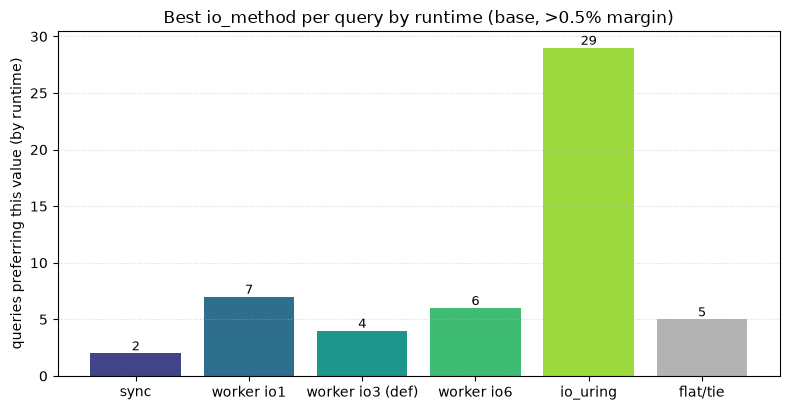

5/53 queries are flat on runtime (no value wins by >0.5%).

Queries that gain most runtime from the largest io_method (base, speedup sync -> io_uring):
qid
q12/base.sql               1.29
q09/base.sql               1.27
q12/v1_materialized.sql    1.26
q12/v2_filter.sql          1.25
q06/v1_materialized.sql    1.24
q09/v1_materialized.sql    1.24
q21/base.sql               1.23
q21/v1_materialized.sql    1.23
q18/base.sql               1.23
q06/base.sql               1.22


In [6]:
MARGIN_PCT = 0.5     # must beat the next value by >this % to "prefer" it

base = data[data["index_status"] == "base"]
m = base.pivot_table(index="qid", columns="pval", values="avg_time_s").reindex(columns=PVALS)
m = m.dropna(how="any")
thr = 1 + MARGIN_PCT / 100.0
arr = m.to_numpy()
order = np.argsort(arr, axis=1)
rows = np.arange(len(arr))
best = arr[rows, order[:, 0]]; runner = arr[rows, order[:, 1]]
winner = np.where(runner > best * thr,
                  np.array(PVALS)[order[:, 0]].astype(object), "flat/tie")
pref = pd.Series(winner, index=m.index)
counts = pref.value_counts()

labels = [p_label(v) for v in PVALS] + ["flat/tie"]
vals = [int(counts.get(v, 0)) for v in PVALS] + [int(counts.get("flat/tie", 0))]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(range(len(labels)), vals,
       color=list(plt.cm.viridis(np.linspace(0.2, 0.85, len(PVALS)))) + [(0.7, 0.7, 0.7, 1)])
for i, v in enumerate(vals):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_ylabel("queries preferring this value (by runtime)")
ax.set_title(f"Best io_method per query by runtime (base, >{MARGIN_PCT:g}% margin)")
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()

print(f"{int((pref == 'flat/tie').sum())}/{len(pref)} queries are flat on runtime "
      f"(no value wins by >{MARGIN_PCT:g}%).")
print("\nQueries that gain most runtime from the largest io_method (base, "
      f"speedup {p_label(PVALS[0])} -> {p_label(PVALS[-1])}):")
gain = (m[PVALS[0]] / m[PVALS[-1]]).sort_values(ascending=False)
print(gain.head(10).round(2).to_string())

## 6b. Full ranking by runtime — how every value places across queries

Section 6 counted only each query's *winner*. This ranks **all** io_method values
per query into 1st / 2nd / 3rd / … place (base **runtimes**) with the same
`MARGIN_PCT`: values within that margin of a place's best **share** that place.
Every bar therefore totals the query count, coloured by the place that value took
— a mostly-green value is the safe default; lots of red means it is usually the
worst choice.

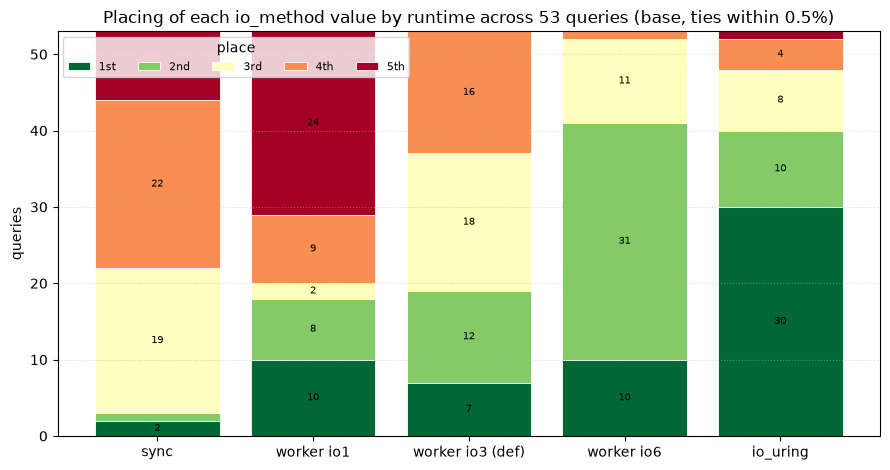

runtime placings across 53 queries (ties within 0.5% share a place):
                  1st  2nd  3rd  4th  5th
sync                2    1   19   22    9
worker io1         10    8    2    9   24
worker io3 (def)    7   12   18   16    0
worker io6         10   31   11    1    0
io_uring           30   10    8    4    1


In [11]:
MARGIN_PCT = 0.5     # values within this % of a place's best share that place

base = data[data["index_status"] == "base"]
m = base.pivot_table(index="qid", columns="pval", values="avg_time_s").reindex(columns=PVALS)
m = m.dropna(how="any")


def positions(row):
    place, gbest = 0, None
    out = {}
    for k in sorted(PVALS, key=lambda kk: row[kk]):
        if gbest is None or row[k] > gbest * (1 + MARGIN_PCT / 100.0):
            place += 1
            gbest = row[k]
        out[k] = place
    return pd.Series(out)


posdf = m.apply(positions, axis=1)          # qid x pval -> place (1..)
maxpos = int(posdf.to_numpy().max())
counts = {v: posdf[v].value_counts() for v in PVALS}


def ordinal(k):
    return {1: "1st", 2: "2nd", 3: "3rd"}.get(k, f"{k}th")


def place_colour(p):
    frac = 1.0 if maxpos == 1 else (maxpos - p) / (maxpos - 1)
    return plt.cm.RdYlGn(frac)


fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(PVALS))
bottom = np.zeros(len(PVALS))
for p in range(1, maxpos + 1):
    vals = np.array([int(counts[v].get(p, 0)) for v in PVALS], dtype=float)
    ax.bar(x, vals, bottom=bottom, color=place_colour(p), label=ordinal(p),
           edgecolor="white", linewidth=0.6)
    for xi, (vv, b) in enumerate(zip(vals, bottom)):
        if vv >= 2:
            ax.text(xi, b + vv / 2, int(vv), ha="center", va="center", fontsize=7)
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels([p_label(v) for v in PVALS])
ax.set_ylabel("queries")
ax.set_title(f"Placing of each io_method value by runtime across {len(m)} queries "
             f"(base, ties within {MARGIN_PCT:g}%)")
ax.legend(title="place", fontsize=8, ncol=maxpos)
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()
fig.savefig("iom_placing.png", dpi=300, bbox_inches="tight")

summary = pd.DataFrame(
    {ordinal(p): [int(counts[v].get(p, 0)) for v in PVALS]
     for p in range(1, maxpos + 1)},
    index=[p_label(v) for v in PVALS])
print(f"runtime placings across {len(m)} queries (ties within {MARGIN_PCT:g}% share a place):")
print(summary.to_string())

## 6c. Best io_method per query — by energy

The same tally as §6, but ranking each query's values by **package energy**
(`avg_pkg_j`) instead of runtime. Because energy = power × time and power is not
constant across settings (e.g. more parallel workers draw more watts), the
lowest-energy value can differ from the fastest one — this is where that shows up.

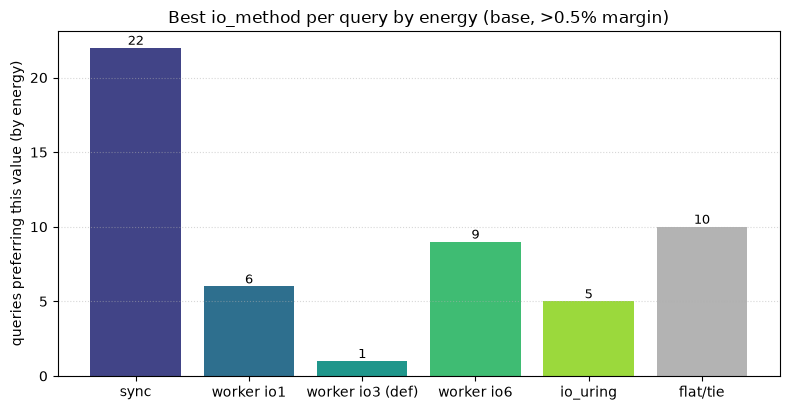

10/53 queries are flat on energy (no value wins by >0.5%).

Queries that gain most energy from the largest io_method (base, energy ratio sync -> io_uring):
qid
q07/v1_materialized.sql     1.14
q11/v2_cte_threshold.sql    1.12
q02/v2_decorrelate.sql      1.11
q07/v2_union_all.sql        1.09
q16/base.sql                1.09
q16/v1_materialized.sql     1.06
q16/v2_not_exists.sql       1.04
q07/base.sql                1.03
q19/base.sql                1.02
q09/base.sql                1.02


In [8]:
MARGIN_PCT = 0.5     # must beat the next value by >this % to "prefer" it

base = data[data["index_status"] == "base"]
m = base.pivot_table(index="qid", columns="pval", values="avg_pkg_j").reindex(columns=PVALS)
m = m.dropna(how="any")
thr = 1 + MARGIN_PCT / 100.0
arr = m.to_numpy()
order = np.argsort(arr, axis=1)
rows = np.arange(len(arr))
best = arr[rows, order[:, 0]]; runner = arr[rows, order[:, 1]]
winner = np.where(runner > best * thr,
                  np.array(PVALS)[order[:, 0]].astype(object), "flat/tie")
pref = pd.Series(winner, index=m.index)
counts = pref.value_counts()

labels = [p_label(v) for v in PVALS] + ["flat/tie"]
vals = [int(counts.get(v, 0)) for v in PVALS] + [int(counts.get("flat/tie", 0))]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(range(len(labels)), vals,
       color=list(plt.cm.viridis(np.linspace(0.2, 0.85, len(PVALS)))) + [(0.7, 0.7, 0.7, 1)])
for i, v in enumerate(vals):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_ylabel("queries preferring this value (by energy)")
ax.set_title(f"Best io_method per query by energy (base, >{MARGIN_PCT:g}% margin)")
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()

print(f"{int((pref == 'flat/tie').sum())}/{len(pref)} queries are flat on energy "
      f"(no value wins by >{MARGIN_PCT:g}%).")
print("\nQueries that gain most energy from the largest io_method (base, "
      f"energy ratio {p_label(PVALS[0])} -> {p_label(PVALS[-1])}):")
gain = (m[PVALS[0]] / m[PVALS[-1]]).sort_values(ascending=False)
print(gain.head(10).round(2).to_string())

## 6d. Full ranking by energy — how every value places across queries

The §6b placings, but ranking all io_method values per query by **package energy**
rather than runtime. Compare the colours against §6b: a value that is usually
fastest but not usually lowest-energy (or vice-versa) reveals a time-vs-energy
trade-off in this parameter.

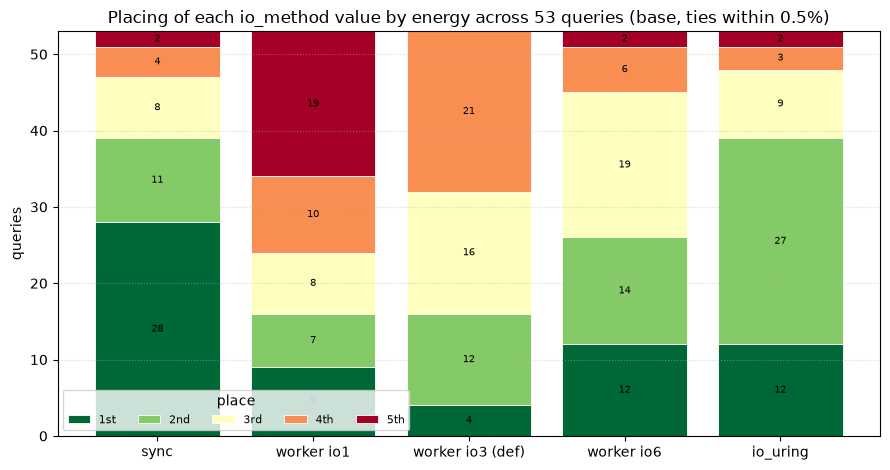

energy placings across 53 queries (ties within 0.5% share a place):
                  1st  2nd  3rd  4th  5th
sync               28   11    8    4    2
worker io1          9    7    8   10   19
worker io3 (def)    4   12   16   21    0
worker io6         12   14   19    6    2
io_uring           12   27    9    3    2


In [12]:
MARGIN_PCT = 0.5     # values within this % of a place's best share that place

base = data[data["index_status"] == "base"]
m = base.pivot_table(index="qid", columns="pval", values="avg_pkg_j").reindex(columns=PVALS)
m = m.dropna(how="any")


def positions(row):
    place, gbest = 0, None
    out = {}
    for k in sorted(PVALS, key=lambda kk: row[kk]):
        if gbest is None or row[k] > gbest * (1 + MARGIN_PCT / 100.0):
            place += 1
            gbest = row[k]
        out[k] = place
    return pd.Series(out)


posdf = m.apply(positions, axis=1)          # qid x pval -> place (1..)
maxpos = int(posdf.to_numpy().max())
counts = {v: posdf[v].value_counts() for v in PVALS}


def ordinal(k):
    return {1: "1st", 2: "2nd", 3: "3rd"}.get(k, f"{k}th")


def place_colour(p):
    frac = 1.0 if maxpos == 1 else (maxpos - p) / (maxpos - 1)
    return plt.cm.RdYlGn(frac)


fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(PVALS))
bottom = np.zeros(len(PVALS))
for p in range(1, maxpos + 1):
    vals = np.array([int(counts[v].get(p, 0)) for v in PVALS], dtype=float)
    ax.bar(x, vals, bottom=bottom, color=place_colour(p), label=ordinal(p),
           edgecolor="white", linewidth=0.6)
    for xi, (vv, b) in enumerate(zip(vals, bottom)):
        if vv >= 2:
            ax.text(xi, b + vv / 2, int(vv), ha="center", va="center", fontsize=7)
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels([p_label(v) for v in PVALS])
ax.set_ylabel("queries")
ax.set_title(f"Placing of each io_method value by energy across {len(m)} queries "
             f"(base, ties within {MARGIN_PCT:g}%)")
ax.legend(title="place", fontsize=8, ncol=maxpos)
ax.grid(axis="y", linestyle=":", alpha=0.5)
fig.tight_layout(); plt.show()
fig.savefig("iom_placing_energy.png", dpi=300, bbox_inches="tight")

summary = pd.DataFrame(
    {ordinal(p): [int(counts[v].get(p, 0)) for v in PVALS]
     for p in range(1, maxpos + 1)},
    index=[p_label(v) for v in PVALS])
print(f"energy placings across {len(m)} queries (ties within {MARGIN_PCT:g}% share a place):")
print(summary.to_string())

## 7. Indexing vs io_method — which lever matters more?

Two ways to make a query faster: tune io_method, or add an index. This compares,
per query, the **io_method speedup** (base runtime at the smallest vs largest
setting) against the **indexing speedup** (base vs indexed at a fixed, common
setting). Points above the diagonal are helped more by an index; points to the
right are helped more by tuning io_method.

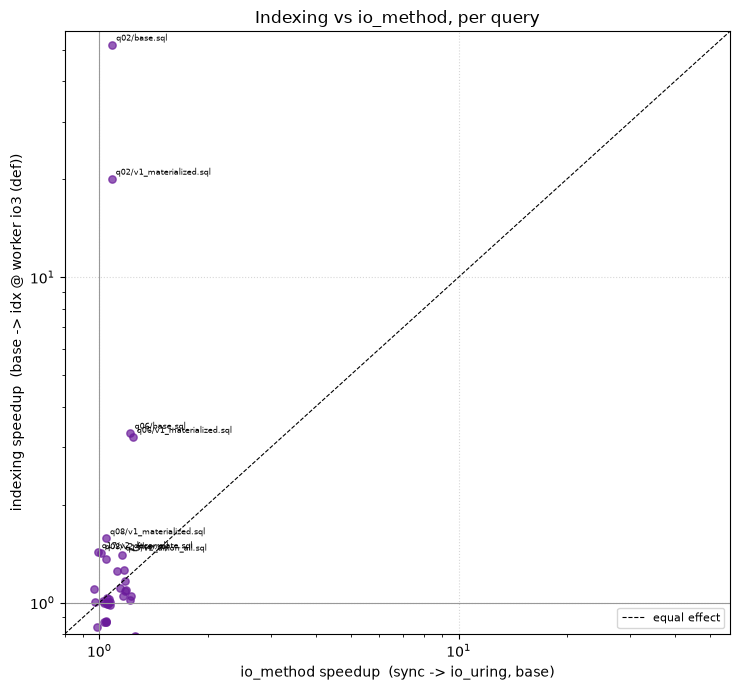

At worker io3 (def): indexing beats io_method tuning for 13/53 queries; io_method wins for 40.


In [10]:
common_pv = [m for m in PVALS
             if {"base", "idx"} <= set(data.loc[data["pval"] == m, "index_status"])]
if not common_pv:
    print("No io_method value has both base and indexed runs - "
          "cannot compare indexing vs io_method yet.")
else:
    fix = common_pv[len(common_pv) // 2]           # a middle common value
    base = data[data["index_status"] == "base"]
    rt = base.pivot_table(index="qid", columns="pval", values="avg_time_s").reindex(columns=PVALS)
    tuning = (rt[PVALS[0]] / rt[PVALS[-1]]).rename("tuning_x")

    bt = data[(data["index_status"] == "base") & (data["pval"] == fix)].set_index("qid")["avg_time_s"]
    it = data[(data["index_status"] == "idx") & (data["pval"] == fix)].set_index("qid")["avg_time_s"]
    indexing = (bt / it).rename("indexing_x")

    comp = pd.concat([tuning, indexing], axis=1).dropna()
    comp = comp[(comp["tuning_x"] > 0) & (comp["indexing_x"] > 0)]
    fig, ax = plt.subplots(figsize=(7.5, 7))
    ax.scatter(comp["tuning_x"], comp["indexing_x"], s=28, alpha=0.7, color="#6a1b9a")
    lim = [0.8, max(3.0, comp.to_numpy().max() * 1.1)]
    ax.plot(lim, lim, color="k", lw=0.8, ls="--", label="equal effect")
    ax.axhline(1, color="0.6", lw=0.8); ax.axvline(1, color="0.6", lw=0.8)
    for q, row in comp.sort_values(["indexing_x", "tuning_x"]).tail(8).iterrows():
        ax.annotate(q, (row["tuning_x"], row["indexing_x"]), fontsize=6,
                    xytext=(3, 3), textcoords="offset points")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"io_method speedup  ({p_label(PVALS[0])} -> {p_label(PVALS[-1])}, base)")
    ax.set_ylabel(f"indexing speedup  (base -> idx @ {p_label(fix)})")
    ax.set_title("Indexing vs io_method, per query")
    ax.legend(fontsize=8); ax.grid(linestyle=":", alpha=0.5)
    fig.tight_layout(); plt.show()

    idx_wins = int((comp["indexing_x"] > comp["tuning_x"]).sum())
    print(f"At {p_label(fix)}: indexing beats io_method tuning for {idx_wins}/{len(comp)} "
          f"queries; io_method wins for {len(comp) - idx_wins}.")